In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, to_hex, BoundaryNorm
from matplotlib.patches import Patch
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list, fcluster
from pathlib import Path

import sys
sys.path.append("../../../scripts")
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

In [8]:
m2or = pd.read_csv("/home/izirdeli/Documents.cglab/olfactory-receptors/Model/Data_Preparation/processed/m2or_pairs_model.csv")

In [9]:
m2or.columns

Index(['Species', 'UniProt ID', 'Sequence', 'SMILES', 'Mixture', 'Responsive',
       'seq_id', 'smiles_id', 'mutation', 'Class'],
      dtype='object')

In [6]:
# counts per (seq_id, smiles_id, InChIKey)
counts = (
    m2or.dropna(subset=["seq_id", "smiles_id", "InChIKey"])
       .groupby(["seq_id", "smiles_id", "InChIKey"])
       .size()
       .reset_index(name="n")
)

# keep only those that appear once
once_in_pair = counts[counts["n"] == 1]

once_in_pair  # rows: (seq_id, smiles_id, InChIKey) that occur exactly once

,seq_id,smiles_id,InChIKey,n
0,SEQ0000,SML0000,XMGQYMWWDOXHJM-SNVBAGLBSA-N,1
1,SEQ0000,SML0001,ULDHMXUKGWMISQ-VIFPVBQESA-N,1
2,SEQ0000,SML0002,NOOLISFMXDJSKH-AEJSXWLSSA-N,1
3,SEQ0000,SML0003,LRHPLDYGYMQRHN-UHFFFAOYSA-N,1
4,SEQ0000,SML0004,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,1
...,...,...,...,...
53052,SEQ1397,SML0770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,1
53053,SEQ1398,SML0770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,1
53054,SEQ1399,SML0770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,1
53055,SEQ1400,SML0770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,1


In [3]:
fu = pd.read_csv("fuckin_classes.csv")
fu

,seq_id,Class
0,UP:A0A0G2JNH3,class 2
1,UP:A0A286YEU6,class 2
2,UP:A0A2R8Y4L6,class 2
3,UP:A0A2R8YED5,class 2
4,UP:A0A2R8YEH3,class 2
5,UP:A0A3B3IT45,class 1
6,UP:A0AAG2UY17,class 2
7,UP:P0DMU2,class 2
8,UP:Q8NGA2,class 2
9,UP:Q8NGI1,class 1


In [4]:
inchis = m2or[["InChIKey", "smiles_id"]]
inchis.drop_duplicates(inplace=True)
#inchis

/tmp/ipykernel_1430086/2749167621.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inchis.drop_duplicates(inplace=True)


In [7]:
#predictions = pd.read_csv("/home/izirdeli/Documents.cglab/OLFACTION/analysis/scripts/testing_runs/median_probs_human_long.csv")  # TODO: update path
predictions = pd.read_csv("../../../predictions/aggregated/Reference_Tree_Predictions/reference_prediction_prob_ge_0.6_wide.csv")
#predictions

In [8]:
predictions 

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,9606.A0A096LPK9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9606.A0A0G2JNH3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9606.A0A0X1KG70,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9606.A0A286YEU6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9606.A0A2R8Y4L6,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,9606.Q9Y3N9,1,1,1,1,1,1,1,1,0,...,1,1,1,1,0,1,1,0,1,1
429,9606.Q9Y4A9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
430,9606.Q9Y585,0,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
431,9606.Q9Y5P0,0,0,0,0,1,0,0,0,0,...,1,0,1,0,1,0,0,0,0,0


In [10]:
predictions.columns

Index(['protein_id', 'SML0000', 'SML0001', 'SML0002', 'SML0003', 'SML0004',
       'SML0005', 'SML0006', 'SML0007', 'SML0008',
       ...
       'SML0744', 'SML0745', 'SML0746', 'SML0747', 'SML0748', 'SML0749',
       'SML0750', 'SML0768', 'SML0769', 'SML0770'],
      dtype='object', length=755)

In [ ]:
# 1) mapping table from your original dataframe
map_sml_inchi = (
    m2or.dropna(subset=["smiles_id", "InChIKey"])
       .loc[:, ["smiles_id", "InChIKey"]]
       .drop_duplicates()
)

# sanity check: is smiles_id one-to-one with InChIKey?
multi = map_sml_inchi.groupby("smiles_id")["InChIKey"].nunique()
bad = multi[multi > 1]
print("smiles_id with >1 InChIKey:", len(bad))
# if len(bad)>0, we need to decide how to resolve (e.g., keep most frequent)

In [6]:
smi2inchi = dict(zip(inchis["smiles_id"], inchis["InChIKey"]))

lig_cols = [c for c in predictions.columns if c.startswith("SML")]
rename_map = {c: smi2inchi[c] for c in lig_cols if c in smi2inchi}
pred_inchi = predictions.rename(columns=rename_map)

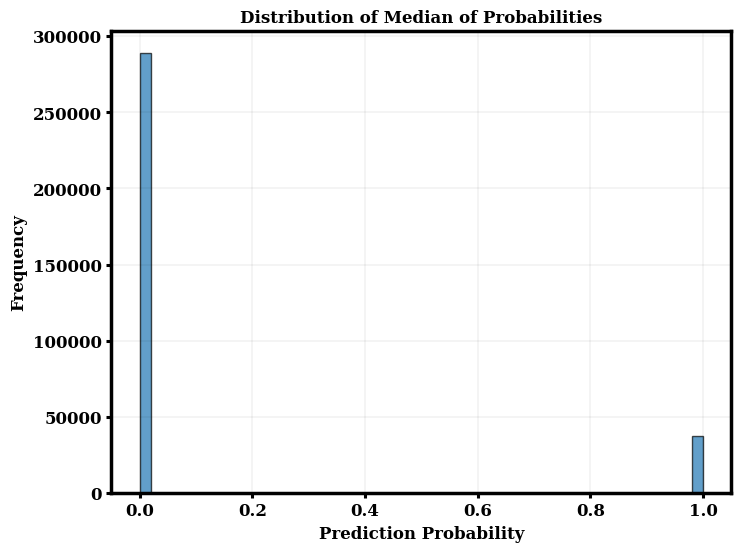

In [7]:
# plot the distribution of values of "pred_inchi" matrix

numeric_cols = pred_inchi.select_dtypes(include=[np.number]).columns
all_values = pred_inchi[numeric_cols].values.flatten()

plt.figure(figsize=(8, 6))
plt.hist(all_values, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel("Prediction Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Median of Probabilities")
plt.grid(True, alpha=0.3)
plt.show()

### arcsine transformation

N                  326482.000000
mean                    0.114129
std                     0.317968
skew                    2.427121
kurtosis_excess         3.890940
mass_at_0               0.885871
mass_at_1               0.114129
q01                     0.000000
q05                     0.000000
q50                     0.000000
q95                     1.000000
q99                     1.000000
dtype: float64
Beta fit: alpha=0.062, beta=0.174


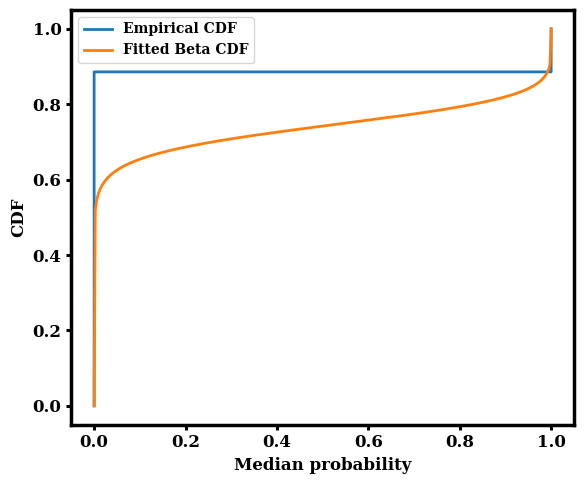

KS vs Beta: stat=0.565, p=0


In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, beta, kstest

# Take only probability columns (your SML/InChIKey columns)
num_cols = pred_inchi.select_dtypes(include=[np.number]).columns
vals = pred_inchi[num_cols].to_numpy().ravel()
vals = vals[~np.isnan(vals)]

eps = 1e-6
vals_clip = np.clip(vals, eps, 1-eps)

summary = {
    "N": vals.size,
    "mean": float(np.mean(vals)),
    "std": float(np.std(vals, ddof=1)),
    "skew": float(skew(vals, bias=False)),
    "kurtosis_excess": float(kurtosis(vals, fisher=True, bias=False)),
    "mass_at_0": float(np.mean(vals == 0.0)),
    "mass_at_1": float(np.mean(vals == 1.0)),
    "q01": float(np.quantile(vals, 0.01)),
    "q05": float(np.quantile(vals, 0.05)),
    "q50": float(np.quantile(vals, 0.50)),
    "q95": float(np.quantile(vals, 0.95)),
    "q99": float(np.quantile(vals, 0.99)),
}
print(pd.Series(summary))

# Fit a Beta(α,β) to (0,1) support (ignore exact 0/1 to avoid infinities)
a,b,loc,scale = beta.fit(vals_clip, floc=0, fscale=1)
print(f"Beta fit: alpha={a:.3f}, beta={b:.3f}")

# Quick ECDF vs fitted beta CDF (good for eyeballing)
x = np.linspace(0,1,400)
ecdf_x = np.sort(vals_clip)
ecdf_y = np.arange(1, ecdf_x.size+1)/ecdf_x.size

plt.figure(figsize=(6,5))
plt.step(ecdf_x, ecdf_y, where='post', label='Empirical CDF')
plt.plot(x, beta.cdf(x, a, b), label='Fitted Beta CDF')
plt.xlabel("Median probability"); plt.ylabel("CDF"); plt.legend(); plt.tight_layout()
plt.show()

# Optional: KS test vs fitted beta
ks_stat, ks_p = kstest(vals_clip, 'beta', args=(a,b), alternative='two-sided')
print(f"KS vs Beta: stat={ks_stat:.3f}, p={ks_p:.3g}")


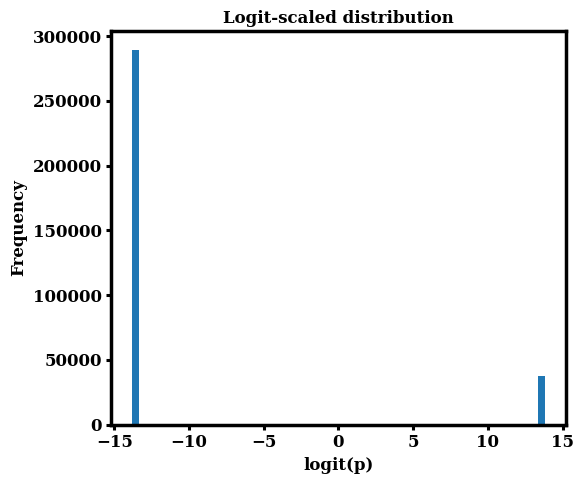

In [10]:
# Logit transform for visualization (not for exact 0/1)
logit_vals = np.log(vals_clip/(1-vals_clip))
plt.figure(figsize=(6,5))
plt.hist(logit_vals, bins=60)
plt.xlabel("logit(p)"); plt.ylabel("Frequency"); plt.title("Logit-scaled distribution")
plt.tight_layout(); plt.show()


### heatmaps

In [8]:
exp_df  = m2or.copy()
pred_df = pred_inchi.copy()

pred_df = pred_df[pred_df['protein_id'].astype(str).str.startswith('9606')].copy()

exp_human = exp_df[exp_df['Species'].str.lower() == 'homo sapiens'].copy()
seq_map = exp_human[['seq_id', 'UniProt ID']].drop_duplicates()
uniprot2seq = dict(zip(seq_map['UniProt ID'], seq_map['seq_id']))

pred_df['UniProt'] = pred_df['protein_id'].apply(lambda x: x.split('.', 1)[1] if '.' in x else x)
pred_df['seq_id']  = pred_df['UniProt'].map(uniprot2seq)
pred_df['row_key'] = np.where(pred_df['seq_id'].notna(), pred_df['seq_id'], 'UP:' + pred_df['UniProt'])

unmapped = pred_df[pred_df['seq_id'].isna()]['UniProt'].unique().tolist()
print(f"[INFO] Unmapped human UniProts kept with 'UP:' keys: {len(unmapped)} -> {unmapped[:20]} ...")

pred_df = pred_df.set_index('row_key').drop(columns=['protein_id','UniProt','seq_id'])

exp_mat = exp_human.pivot_table(index='seq_id',
                                columns='InChIKey',
                                values='Responsive',
                                aggfunc='first')

#common_ligs = exp_mat.columns.intersection(pred_df.columns)
pred_ligs = pred_df.columns  # 754 ligands

common_seqs = exp_mat.index.intersection(pred_df.index)
print("Overlap (common_seqs):", len(common_seqs))  # expect 415

exp_mat_base  = exp_mat.reindex(index=common_seqs, columns=pred_ligs)
pred_mat_base = pred_df.reindex(index=common_seqs, columns=pred_ligs)

extra_seqs = pred_df.index.difference(exp_mat_base.index)
print("Extra human seqs from predictions:", len(extra_seqs))  # expect ~18

extra_rows     = pd.DataFrame(index=extra_seqs, columns=pred_ligs, dtype=float)
exp_mat_ext    = pd.concat([exp_mat_base, extra_rows], axis=0)

pred_mat_ext   = pred_df.reindex(index=exp_mat_ext.index, columns=pred_ligs)

union_mat_ext  = exp_mat_ext.fillna(pred_mat_ext)

print("Final rows (expect 433):", union_mat_ext.shape[0])
print("Final cols (common ligands):", union_mat_ext.shape[1])

[INFO] Unmapped human UniProts kept with 'UP:' keys: 18 -> ['A0A0G2JNH3', 'A0A286YEU6', 'A0A2R8Y4L6', 'A0A2R8YED5', 'A0A2R8YEH3', 'A0A3B3IT45', 'A0AAG2UY17', 'P0DMU2', 'Q8NGA2', 'Q8NGI1', 'Q8NGN7', 'Q8NGU1', 'Q8NGU4', 'Q8NGY7', 'Q8NH95', 'Q8NHA6', 'Q96R84', 'Q9BZC5'] ...
Overlap (common_seqs): 415
Extra human seqs from predictions: 18
Final rows (expect 433): 433
Final cols (common ligands): 754


In [3]:
brbg = mpl.cm.get_cmap('BrBG', 7)
earthy = [to_hex(brbg(i)) for i in range(brbg.N)]
cluster_cmap = ListedColormap(earthy)

/tmp/ipykernel_2373497/2648915094.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  brbg = mpl.cm.get_cmap('BrBG', 7)


In [4]:
earthy

['#543005', '#ae7121', '#e7cf94', '#f5f5f5', '#98d7cd', '#24877f', '#003c30']

/tmp/ipykernel_1430086/2063886057.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  brbg = mpl.cm.get_cmap('BrBG', n_clusters)


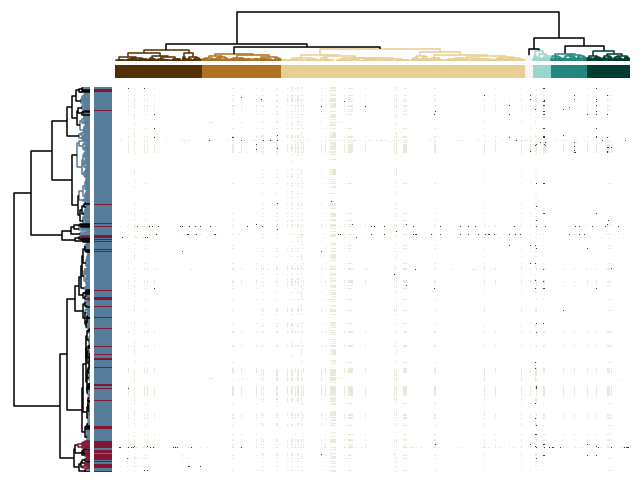

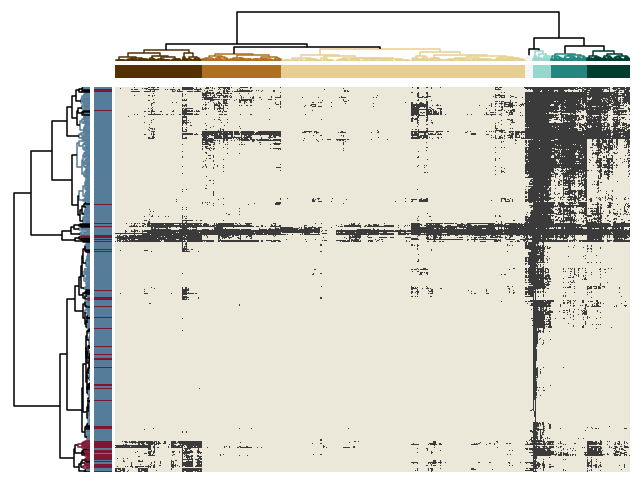

In [9]:
n_clusters = 7

brbg = mpl.cm.get_cmap('BrBG', n_clusters)
earthy = [to_hex(brbg(i)) for i in range(brbg.N)]
cluster_cmap = ListedColormap(earthy)

#-----------------------------------------------------------------------------------------------------------------

row_link = linkage(pdist(union_mat_ext.values, metric='euclidean'), method='ward')
col_link = linkage(pdist(union_mat_ext.values.T, metric='euclidean'), method='ward')
row_order = leaves_list(row_link)
col_order = leaves_list(col_link)

cluster_labels = fcluster(col_link, n_clusters, criterion='maxclust')
cluster_labels_ordered = cluster_labels[col_order]
cluster_stripe = (cluster_labels_ordered - 1).reshape(1, -1)

cluster2color = {lab: earthy[(lab-1) % len(earthy)] for lab in np.unique(cluster_labels)}

def make_link_color_func(linkage_matrix, leaf_clusters):
    def _color(node_id):
        if node_id < len(leaf_clusters):              # leaf
            return cluster2color[leaf_clusters[node_id]]
        left, right = (int(x) for x in linkage_matrix[node_id - len(leaf_clusters), :2])
        c_left, c_right = _color(left), _color(right)
        return c_left if c_left == c_right else 'black'
    return _color

link_cf = make_link_color_func(col_link, cluster_labels)

# exp_ord  = exp_mat_ext.iloc[row_order, col_order]
# pred_ord = pred_mat_ext.iloc[row_order, col_order]


###################################################################################################################

class_map = (exp_human[['seq_id', 'Class']]
             .drop_duplicates()
             .set_index('seq_id')['Class'])

#fu: dataframe with columns ['seq_id', 'Class']
fu['seq_id'] = (
    fu['seq_id']
    .astype(str)
    .str.strip()
)
fu_series = fu.set_index('seq_id')['Class']
class_map = class_map.combine_first(fu_series)
###################################################################################################################


# row_classes = (class_map.reindex(exp_ord.index)
#                         .map({'class 1': 0, 'class 2': 1})
#                         .fillna(2)
#                         .astype(int)
#                         .values.reshape(-1,1))

row_cmap = ListedColormap(['#7f1734', '#557c99'])

heat_cmap = ListedColormap(["#ece8d9", "#3b3b3b"])
heat_cmap.set_bad(color='white')
####################### COLORS PROBS ##########################
# from matplotlib.colors import LinearSegmentedColormap, Normalize

# # same colors you used before, but continuous (light → dark)
# heat_cmap = LinearSegmentedColormap.from_list("binary_to_cont",
#                                               ["#ece8d9", "#3b3b3b"])
# heat_cmap.set_bad("white")  # keep NaNs white
# heat_norm = Normalize(vmin=0.0, vmax=1.0) 
#############################################################


# def add_legends(fig, n_clusters, cluster_colors, row_cmap, heat_cmap, show_missing=True):
#     handles = [
#         Patch(facecolor=heat_cmap(1), label='Active (1)'),
#         Patch(facecolor=heat_cmap(0), label='Inactive (0)'),
#     ]
#     if show_missing:
#         handles.append(Patch(facecolor='white', edgecolor='black', label='Missing'))

#     handles += [
#         Patch(facecolor=row_cmap(0), label='Class 1'),
#         Patch(facecolor=row_cmap(1), label='Class 2'),
#         Patch(facecolor=row_cmap(2), label='Unknown'),
#     ]
#     for lab, col in enumerate(cluster_colors, 1):
#         handles.append(Patch(facecolor=col, label=f'Cluster {lab}'))
#     fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5),
#                frameon=False, fontsize=9)


row_classes_orig = (
    class_map.reindex(union_mat_ext.index)
             .map({'class 1': 0, 'class 2': 1})
             .fillna(2)
             .astype(int)
             .to_numpy()
             .reshape(-1, 1)
)



# Right after creating row_classes_orig, add this:

def _class_hex(cmap, k: int) -> str:
    return to_hex(cmap(int(k)))

def make_link_color_func_by_class(linkage_matrix, leaf_classes, cmap):
    n_leaves = leaf_classes.shape[0]
    def _color(node_id: int) -> str:
        if node_id < n_leaves:
            k = int(leaf_classes[node_id, 0])
            return _class_hex(cmap, k)
        left, right = (int(x) for x in linkage_matrix[node_id - n_leaves, :2])
        c_left  = _color(left)
        c_right = _color(right)
        return c_left if c_left == c_right else '#000000'
    return _color

# Create the row coloring function ONCE, outside plot_pair
row_link_cf = make_link_color_func_by_class(row_link, row_classes_orig, row_cmap)




def plot_pair(data_matrix, title, outdir='./Figures', dpi=300):
    """Plot single panel with dendrogram, enlarged column stripe, row stripe, heatmap."""
    fig = plt.figure(figsize=(8, 6))
    
    stripe_thickness = 0.3
    row_dendro_w     = 1.4
    top_dendro_h     = 1.2
    heat_w           = 9.0
    heat_h           = 9.0
    
    gs = gridspec.GridSpec(4, 3,
                           height_ratios=[top_dendro_h, stripe_thickness, 0.05, heat_h],
                           width_ratios=[row_dendro_w, stripe_thickness, heat_w],
                           hspace=0.03, wspace=0.02)    

    #column dendrogram
    ax_cd = fig.add_subplot(gs[0,2])
    col_d = dendrogram(
        col_link, 
        ax=ax_cd, 
        no_labels=True, 
        color_threshold=0, 
        link_color_func=link_cf,
    )
    
    for coll in ax_cd.collections:
        if isinstance(coll, mpl.collections.LineCollection):
            coll.set_linewidth(1.1)
            coll.set_alpha(1.0)

    ax_cd.axis('off')
    col_leaves = col_d['leaves']

    cluster_labels_ordered = cluster_labels[col_leaves]           # CHANGED
    cluster_stripe_plot = (cluster_labels_ordered - 1).reshape(1, -1)
    ax_colstripe = fig.add_subplot(gs[1,2])
    cluster_norm = BoundaryNorm(np.arange(-0.5, cluster_cmap.N + 0.5, 1), cluster_cmap.N)
    ax_colstripe.imshow(cluster_stripe_plot, aspect='auto', cmap=cluster_cmap, norm=cluster_norm)

    ax_colstripe.axis('off')
    
    #row dendrogram
    ax_rd = fig.add_subplot(gs[3, 0])
    
    # def _class_hex(cmap, k: int) -> str:
    #     return to_hex(cmap(int(k)))
    
    # def make_link_color_func_by_class(linkage_matrix, leaf_classes, cmap):
    #     n_leaves = leaf_classes.shape[0]
    #     def _color(node_id: int) -> str:
    #         if node_id < n_leaves:              # leaf
    #             k = int(leaf_classes[node_id, 0])
    #             return _class_hex(cmap, k)
    #         left, right = (int(x) for x in linkage_matrix[node_id - n_leaves, :2])
    #         c_left  = _color(left)
    #         c_right = _color(right)
    #         return c_left if c_left == c_right else '#000000'
    #     return _color

    # row_link_cf = make_link_color_func_by_class(row_link, row_classes_orig, row_cmap)
    row_d = dendrogram(
        row_link, 
        ax=ax_rd, 
        orientation='left', 
        no_labels=True, 
        color_threshold=0, 
        link_color_func=row_link_cf, 
    )
    
    
    for coll in ax_rd.collections:
        if isinstance(coll, mpl.collections.LineCollection):
            coll.set_linewidth(1.1)
            coll.set_alpha(1.0)

    ax_rd.margins(x=0.01)
    ax_rd.axis('off')
    row_leaves = row_d['leaves']
    
    row_norm = BoundaryNorm(np.arange(-0.5, row_cmap.N + 0.5, 1), row_cmap.N)
    
    row_classes_plot = row_classes_orig[row_leaves, :]
    row_classes_plot = np.flipud(row_classes_plot)
    
    
    
    ax_rowstripe = fig.add_subplot(gs[3,1])
    ax_rowstripe.imshow(row_classes_plot, aspect='auto', cmap=row_cmap, norm=row_norm)
    ax_rowstripe.axis('off')
    
    

    data_matrix_plot = data_matrix[np.ix_(row_leaves, col_leaves)]
    data_matrix_plot = np.flipud(data_matrix_plot)   
    ax_h = fig.add_subplot(gs[3,2])
    ax_h.imshow(data_matrix_plot, aspect='auto', interpolation='none', cmap=heat_cmap)#, norm=heat_norm)
    ax_h.axis('off')

    #fig.suptitle(title, y=0.93, fontsize=12, fontweight='bold')
    
    #add_legends(fig, n_clusters, earthy, row_cmap, heat_cmap, show_missing=True)
    
    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig.savefig(Path(outdir) / f"{fname}.svg",
                bbox_inches='tight',
                transparent=True,
                format='svg')
    
    plt.show()
    plt.close(fig)

#print('Row cmap hex:', [to_hex(c) for c in row_cmap.colors])



Path('./Figures').mkdir(exist_ok=True)
plot_pair(np.ma.masked_invalid(exp_mat_ext.values), f'Experimental preds (k={n_clusters})', outdir='./Figures')
plot_pair(pred_mat_ext.values, f'Predicted preds (k={n_clusters})', outdir='./Figures')

/tmp/ipykernel_1430086/2170715768.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  brbg = mpl.cm.get_cmap('BrBG', n_clusters)


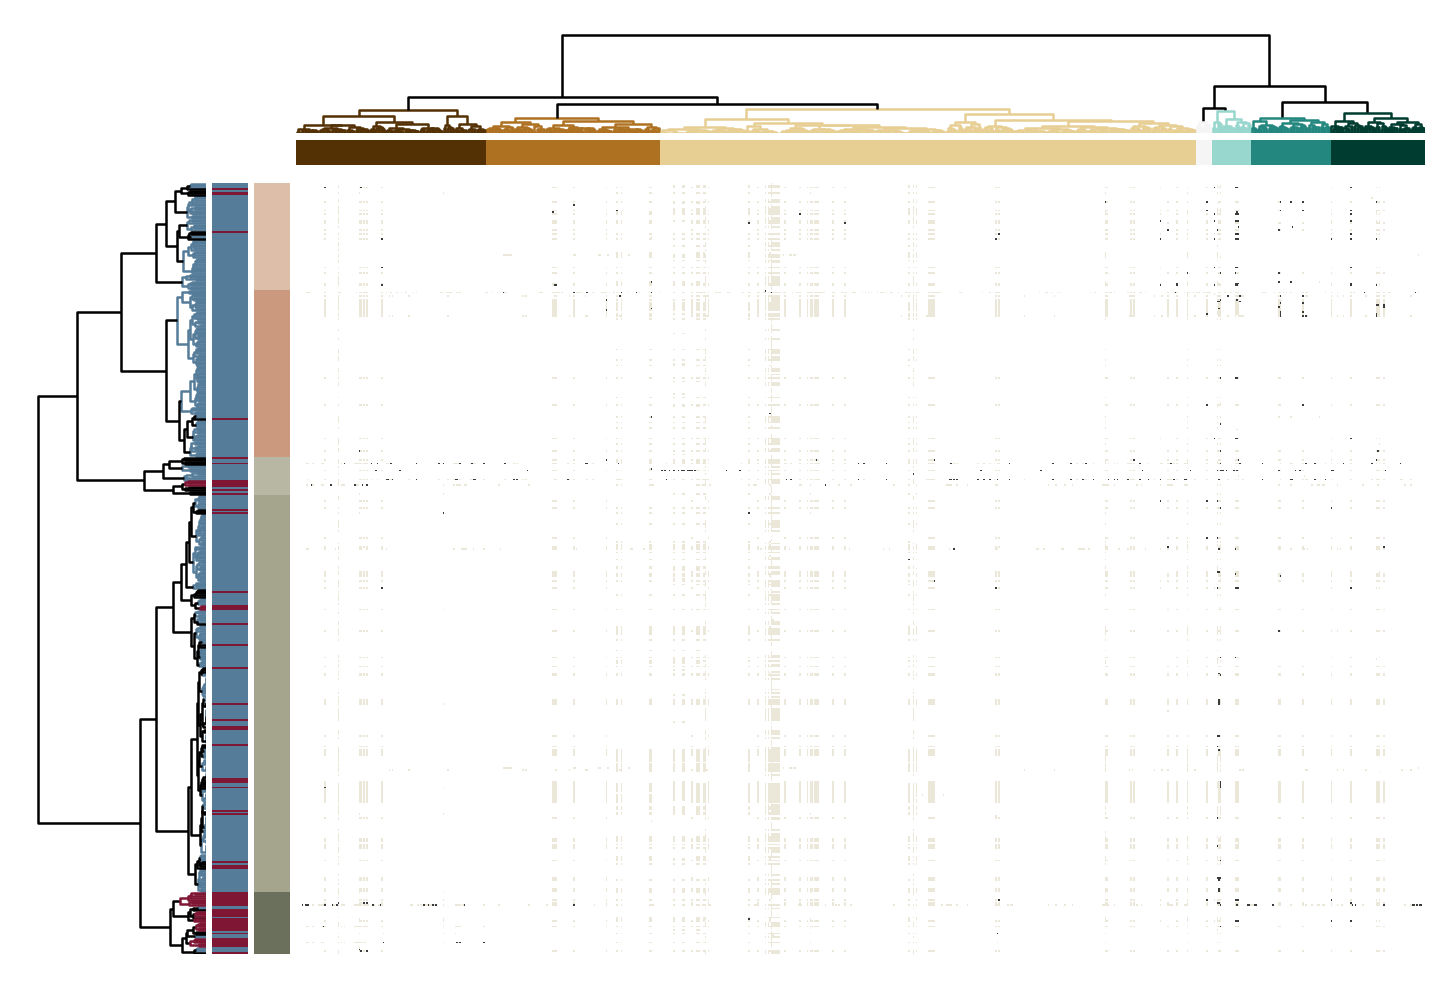

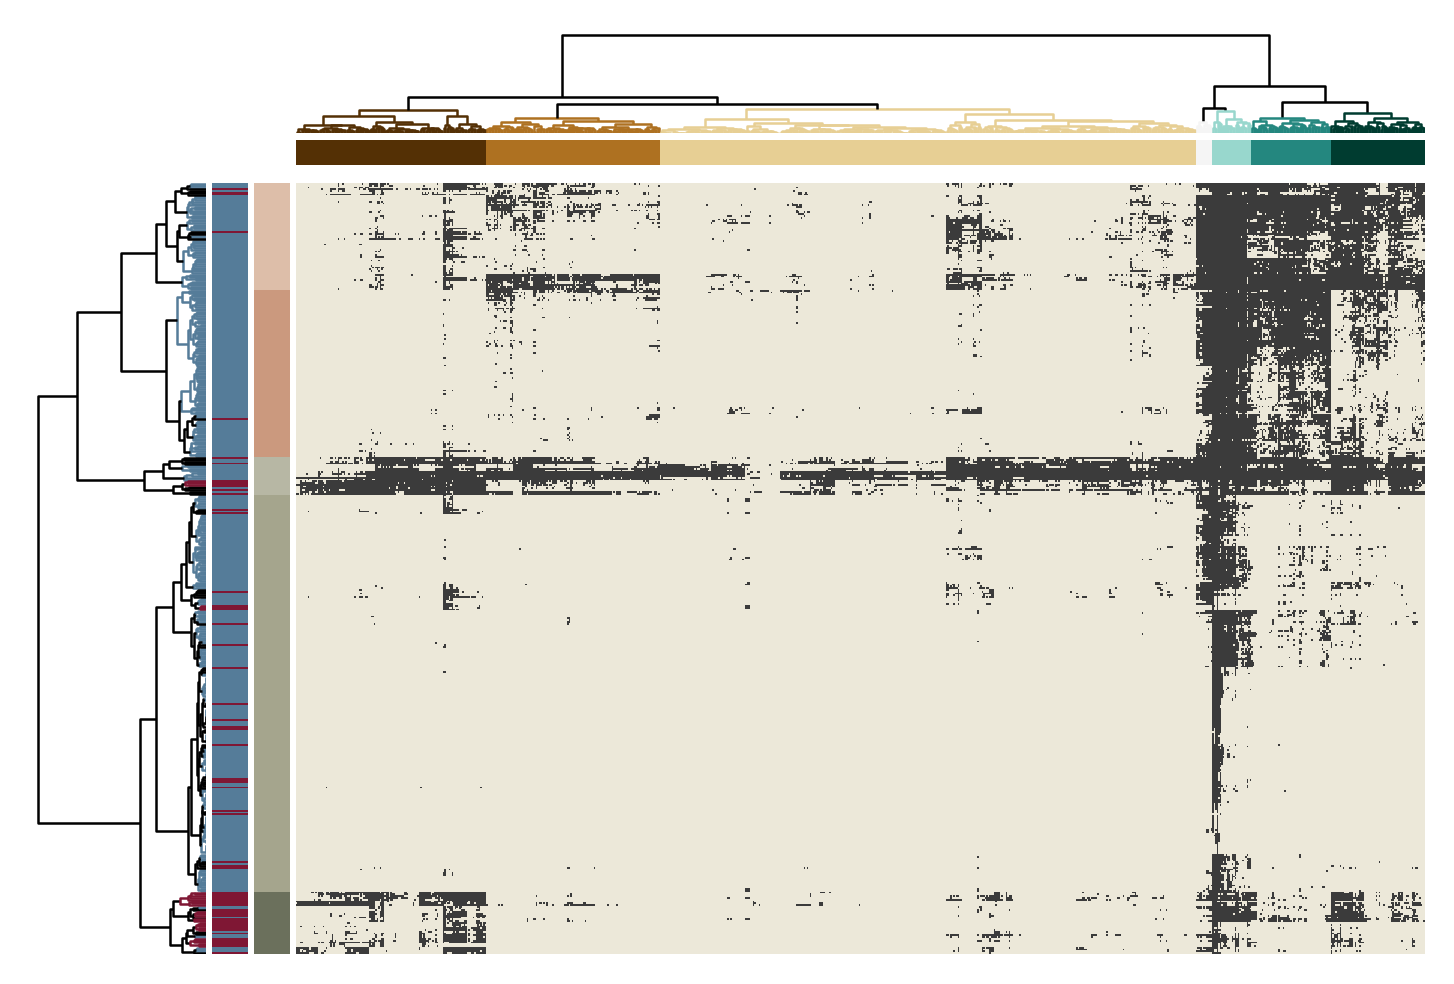

In [10]:
# =======================
# Clustering + Palettes
# =======================
n_clusters = 7

brbg = mpl.cm.get_cmap('BrBG', n_clusters)
earthy = [to_hex(brbg(i)) for i in range(brbg.N)]
cluster_cmap = ListedColormap(earthy)

# --- row/col linkages for the main heatmap (same as your code)
row_link = linkage(pdist(union_mat_ext.values, metric='euclidean'), method='ward')
col_link = linkage(pdist(union_mat_ext.values.T, metric='euclidean'), method='ward')
row_order = leaves_list(row_link)
col_order = leaves_list(col_link)

# --- column clusters + stripe colors
cluster_labels = fcluster(col_link, n_clusters, criterion='maxclust')
cluster_labels_ordered = cluster_labels[col_order]
cluster_stripe = (cluster_labels_ordered - 1).reshape(1, -1)

cluster2color = {lab: earthy[(lab-1) % len(earthy)] for lab in np.unique(cluster_labels)}

def make_link_color_func(linkage_matrix, leaf_clusters):
    def _color(node_id):
        if node_id < len(leaf_clusters):              # leaf
            return cluster2color[leaf_clusters[node_id]]
        left, right = (int(x) for x in linkage_matrix[node_id - len(leaf_clusters), :2])
        c_left, c_right = _color(left), _color(right)
        return c_left if c_left == c_right else 'black'
    return _color

link_cf = make_link_color_func(col_link, cluster_labels)

# =======================
# Class map (your code)
# =======================
class_map = (exp_human[['seq_id', 'Class']]
             .drop_duplicates()
             .set_index('seq_id')['Class'])

fu['seq_id'] = fu['seq_id'].astype(str).str.strip()
fu_series = fu.set_index('seq_id')['Class']
class_map = class_map.combine_first(fu_series)

# NOTE: you set only two colors below; we'll clip any "unknown" to class 1 (blue) for plotting
row_cmap = ListedColormap(['#7f1734', '#557c99'])   # 0=class1 (red-ish), 1=class2 (blue-ish)

heat_cmap = ListedColormap(["#ece8d9", "#3b3b3b"])
heat_cmap.set_bad(color='white')

row_classes_orig = (
    class_map.reindex(union_mat_ext.index)
             .map({'class 1': 0, 'class 2': 1})
             .fillna(2)  # may exist, but we clip to {0,1} for display below
             .astype(int)
             .to_numpy()
             .reshape(-1, 1)
)

# =======================
# Row dendrogram coloring by class (your function)
# =======================
def _class_hex(cmap, k: int) -> str:
    return to_hex(cmap(int(k)))

def make_link_color_func_by_class(linkage_matrix, leaf_classes, cmap):
    n_leaves = leaf_classes.shape[0]
    def _color(node_id: int) -> str:
        if node_id < n_leaves:              # leaf
            k = int(leaf_classes[node_id, 0])
            # clip unknowns to 1 so colormap with 2 entries won't crash
            k = 1 if k > 1 else k
            return _class_hex(cmap, k)
        left, right = (int(x) for x in linkage_matrix[node_id - n_leaves, :2])
        c_left  = _color(left)
        c_right = _color(right)
        return c_left if c_left == c_right else '#000000'
    return _color

row_link_cf = make_link_color_func_by_class(row_link, row_classes_orig, row_cmap)

# =======================
# EXTRA: Row clusters from a binary matrix (threshold 0.6)
# =======================
from scipy.cluster.hierarchy import fcluster

binary_mat = (union_mat_ext >= 0.6).astype(int)

# cluster rows on the binary calls (as you sketched)
row_link_bin = linkage(pdist(binary_mat.values, metric='euclidean'), method='ward')
row_leaves_bin = leaves_list(row_link_bin)

# choose how many row clusters you want to visualize
n_row_clusters = 5
row_cluster_labels = fcluster(row_link_bin, n_row_clusters, criterion='maxclust')   # labels in original row index order


# we’ll color the row-cluster stripe with the SAME BrBG palette (wrap if needed)
# import cmocean
# from matplotlib.colors import ListedColormap, BoundaryNorm, to_hex

# base = cmocean.cm.algae
# row_cluster_cmap = ListedColormap([to_hex(base(i / (n_row_clusters - 1))) for i in range(n_row_clusters)])
# row_cluster_norm = BoundaryNorm(np.arange(-0.5, n_row_clusters + 0.5, 1), n_row_clusters)


import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm

# your palette (replace as needed)
earth_accents = [
    "#4F577A", "#4F787A", "#A7C957", "#848F6B", "#8F826B", "#8DAA9D", "#7D7461",
    "#6B8F71","#8DAA9D","#7F7B82","#8DAA9D","#C2A878",
    "#8F5D5D","#4F6D7A","#A7C957","#7D7461","#A26E6A"
]

row_cluster_colors = [
    "#6B705C",  # olive gray
    "#A5A58D",  # dry sage
    "#B7B7A4",  # sand
    "#CB997E",  # clay
    "#DDBEA9",  # soft peach
    "#FFE8D6",  # beige
    "#997B66",  # warm soil
    "#5E503F",  # dark bark
]

# build colormap
row_cluster_cmap = ListedColormap(row_cluster_colors[:n_row_clusters])
row_cluster_norm = BoundaryNorm(
    np.arange(-0.5, n_row_clusters + 0.5, 1),
    n_row_clusters
)



# =======================
# Plotting (adds a NEW stripe column for row clusters)
# =======================
def plot_pair(data_matrix, title, outdir='./Figures', dpi=300):
    """Panel with:
       - Column dendrogram
       - Column cluster stripe
       - Row dendrogram (class-colored)
       - Row CLASS stripe  (left of row-cluster stripe)
       - Row CLUSTER stripe  (BrBG; immediately next to heatmap)
       - Heatmap
    """
    fig = plt.figure(figsize=(6, 4), dpi=dpi)

    stripe_thickness_class   = 0.28
    stripe_thickness_rowcl   = 0.28
    row_dendro_w             = 1.4
    top_dendro_h             = 1.2
    heat_w                   = 9.0
    heat_h                   = 9.0

    # Four columns now: [row dendro | class stripe | row-cluster stripe | heatmap]
    gs = gridspec.GridSpec(
        4, 4,
        height_ratios=[top_dendro_h, 0.3, 0.05, heat_h],
        width_ratios=[row_dendro_w, stripe_thickness_class, stripe_thickness_rowcl, heat_w],
        hspace=0.03, wspace=0.02
    )
    

    # --- Column dendrogram & stripe (now at last column index=3) ---
    ax_cd = fig.add_subplot(gs[0, 3])
    col_d = dendrogram(
        col_link,
        ax=ax_cd,
        no_labels=True,
        color_threshold=0,
        link_color_func=link_cf,
    )
    for coll in ax_cd.collections:
        if isinstance(coll, mpl.collections.LineCollection):
            coll.set_linewidth(0.6)
            coll.set_alpha(1.0)
    ax_cd.axis('off')
    col_leaves = col_d['leaves']

    # Column cluster stripe (ordered by col_leaves)
    cluster_labels_ordered = cluster_labels[col_leaves]
    cluster_stripe_plot = (cluster_labels_ordered - 1).reshape(1, -1)
    ax_colstripe = fig.add_subplot(gs[1, 3])
    cluster_norm = BoundaryNorm(np.arange(-0.5, cluster_cmap.N + 0.5, 1), cluster_cmap.N)
    ax_colstripe.imshow(cluster_stripe_plot, aspect='auto', cmap=cluster_cmap, norm=cluster_norm)
    ax_colstripe.axis('off')

    # --- Row dendrogram (LEFT), class-colored ---
    ax_rd = fig.add_subplot(gs[3, 0])
    row_d = dendrogram(
        row_link,
        ax=ax_rd,
        orientation='left',
        no_labels=True,
        color_threshold=0,
        link_color_func=row_link_cf,
    )
    for coll in ax_rd.collections:
        if isinstance(coll, mpl.collections.LineCollection):
            coll.set_linewidth(0.6)
            coll.set_alpha(1.0)
    ax_rd.margins(x=0.01)
    ax_rd.axis('off')
    row_leaves = row_d['leaves']

    # --- Row CLASS stripe (ordered + flipped)
    # clip any unknowns (>1) to 1 so it fits the 2-color row_cmap
    row_classes_plot = row_classes_orig[row_leaves, :].clip(max=1)
    row_classes_plot = np.flipud(row_classes_plot)
    row_class_norm = BoundaryNorm(np.arange(-0.5, row_cmap.N + 0.5, 1), row_cmap.N)

    ax_rowstripe_class = fig.add_subplot(gs[3, 1])
    ax_rowstripe_class.imshow(row_classes_plot, aspect='auto', cmap=row_cmap, norm=row_class_norm)
    ax_rowstripe_class.axis('off')

    # --- Row CLUSTER stripe (ordered by the SAME row_leaves + flipped)
    # Map row clusters (computed on binary_mat) to the row_leaves order of the main dendrogram
    row_cluster_for_leaves = row_cluster_labels[row_leaves]   # labels 1..n_row_clusters
    row_cluster_for_plot = (row_cluster_for_leaves - 1)[::-1].reshape(-1, 1)  # 0-based + flipped

    ax_rowstripe_rcl = fig.add_subplot(gs[3, 2])
    ax_rowstripe_rcl.imshow(row_cluster_for_plot, aspect='auto', cmap=row_cluster_cmap, norm=row_cluster_norm)
    ax_rowstripe_rcl.axis('off')

    # --- Heatmap (ordered + flipped vertically to align with stripes)
    data_matrix_plot = data_matrix[np.ix_(row_leaves, col_leaves)]
    data_matrix_plot = np.flipud(data_matrix_plot)
    ax_h = fig.add_subplot(gs[3, 3])
    ax_h.imshow(data_matrix_plot, aspect='auto', interpolation='none', cmap=heat_cmap)  # keep your original no-norm
    ax_h.axis('off')

    # Save
    Path(outdir).mkdir(exist_ok=True, parents=True)
    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig.savefig(Path(outdir) / f"{fname}.png", bbox_inches='tight', transparent=True, format='png')
    plt.show()
    plt.close(fig)

# Run both panels
Path('./Figures').mkdir(exist_ok=True)
plot_pair(np.ma.masked_invalid(exp_mat_ext.values), f'Experimental preds (k={n_clusters})', outdir='./Figures')
plot_pair(pred_mat_ext.values,                       f'Predicted preds (k={n_clusters})',   outdir='./Figures')


In [11]:
# ---------- Legend builders ----------
from matplotlib.patches import Patch
from math import ceil

def _discrete_colors_from_cmap(cmap, n):
    """Return n colors from a ListedColormap or any Colormap."""
    if getattr(cmap, "colors", None) is not None and len(cmap.colors) >= n:
        return list(cmap.colors[:n])
    denom = max(n-1, 1)
    return [cmap(i/denom) for i in range(n)]

def build_legend_handles_full(n_clusters, cluster_cmap, n_row_clusters, row_cluster_cmap,
                              row_cmap, heat_cmap, show_missing=False):
    handles = []

    # Heatmap states
    handles += [
        Patch(facecolor=heat_cmap(1.0), label='Active (1)'),
        Patch(facecolor=heat_cmap(0.0), label='Inactive (0)'),
        Patch(facecolor='white', edgecolor='0.5', label='Missing')
    ]
    if show_missing:
        handles.append(Patch(facecolor='white', edgecolor='0.5', label='Missing'))

    # Row classes (this also explains row-dendrogram coloring)
    handles += [
        Patch(facecolor=row_cmap(0.0), label='Class 1'),
        Patch(facecolor=row_cmap(1.0), label='Class 2'),
    ]

    # Column clusters (BrBG)
    col_cluster_cols = _discrete_colors_from_cmap(cluster_cmap, n_clusters)
    handles += [Patch(facecolor=col_cluster_cols[i], label=f'Col Cluster {i+1}')
                for i in range(n_clusters)]

    # Row clusters (your custom palette)
    row_cluster_cols = _discrete_colors_from_cmap(row_cluster_cmap, n_row_clusters)
    handles += [Patch(facecolor=row_cluster_cols[i], label=f'Row Cluster {i+1}')
                for i in range(n_row_clusters)]

    return handles

def add_side_legend(fig, handles, anchor=(1.02, 0.5), ncol=1, fontsize=9, title=None):
    return fig.legend(handles=handles, loc='center left', bbox_to_anchor=anchor,
                      frameon=False, ncol=ncol, title=title,
                      fontsize=fontsize, title_fontsize=fontsize)

def save_legend(handles, path, ncol=1, fontsize=9, title=None, dpi=300):
    # simple size heuristic
    h = 0.40 * ceil(len(handles) / ncol) + 0.5
    w = 2.3 * ncol
    fig = plt.figure(figsize=(w, h))
    fig.legend(handles=handles, loc='center', frameon=False, ncol=ncol,
               title=title, fontsize=fontsize, title_fontsize=fontsize)
    fig.savefig(path, bbox_inches='tight', dpi=dpi, transparent=True)
    plt.close(fig)


In [12]:
# outside plot_pair, once
handles = build_legend_handles_full(
    n_clusters, cluster_cmap, n_row_clusters, row_cluster_cmap, row_cmap, heat_cmap,
    show_missing=False
)
save_legend(handles, './Figures/legend_full.png', ncol=1, fontsize=9)


In [13]:
from scipy.cluster.hierarchy import fcluster

# 1. Build the binary call matrix using the threshold = 0.6
binary_mat = (union_mat_ext >= 0.6).astype(int)

# 2. Row clustering on the same distance/linkage you’ve been using
row_link_bin = linkage(pdist(binary_mat.values, metric='euclidean'), method='ward')
row_leaves_bin = leaves_list(row_link_bin)

# 3. Cut the dendrogram into row clusters
#    You can tune this number. Let's start with 6.
n_row_clusters = 5
row_cluster_labels = fcluster(row_link_bin, n_row_clusters, criterion='maxclust')

# Reorder according to dendrogram leaves, so we know which cluster sits where visually
row_cluster_labels_ordered = row_cluster_labels[row_leaves_bin]
receptors_in_order = np.array(binary_mat.index)[row_leaves_bin]

# 4. Summarize each row cluster
row_summary = []
for cl in np.unique(row_cluster_labels_ordered):
    idx = np.where(row_cluster_labels_ordered == cl)[0]
    these_receptors = receptors_in_order[idx]

    submat = binary_mat.loc[these_receptors]

    # how broad on average? fraction of ligands called active per receptor
    receptor_activity_fraction = submat.mean(axis=1)  # vector: for each receptor, % ligands active
    mean_active_fraction = receptor_activity_fraction.mean()

    # class composition
    classes_here = class_map.reindex(these_receptors).fillna("unknown")
    class_counts = classes_here.value_counts().to_dict()

    row_summary.append({
        "row_cluster": cl,
        "n_receptors": len(these_receptors),
        "mean_active_fraction": float(mean_active_fraction),
        "overall_binding_density": float(submat.values.mean()),
        "class_counts": class_counts,
        "example_receptors": list(these_receptors[:5])
    })

row_summary


[{'row_cluster': 1,
  'n_receptors': 35,
  'mean_active_fraction': 0.12008336491095112,
  'overall_binding_density': 0.12008336491095112,
  'class_counts': {'class 1': 26, 'class 2': 9},
  'example_receptors': ['SEQ0898',
   'SEQ0346',
   'SEQ0567',
   'SEQ0583',
   'SEQ1376']},
 {'row_cluster': 2,
  'n_receptors': 223,
  'mean_active_fraction': 0.023872679045092837,
  'overall_binding_density': 0.023872679045092837,
  'class_counts': {'class 2': 200, 'class 1': 23},
  'example_receptors': ['SEQ0149',
   'SEQ0431',
   'SEQ1340',
   'SEQ1282',
   'SEQ0834']},
 {'row_cluster': 3,
  'n_receptors': 21,
  'mean_active_fraction': 0.5942907667045597,
  'overall_binding_density': 0.5942907667045598,
  'class_counts': {'class 2': 13, 'class 1': 8},
  'example_receptors': ['SEQ0955',
   'SEQ1353',
   'SEQ1400',
   'SEQ1361',
   'SEQ1391']},
 {'row_cluster': 4,
  'n_receptors': 94,
  'mean_active_fraction': 0.11655567469947518,
  'overall_binding_density': 0.11655567469947514,
  'class_counts': {

Row display order shape: (433,)
Cluster labels in display order (top→bottom) first 30:
[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1]
Boundary row indices (top→bottom): [ 60 154 175 398]


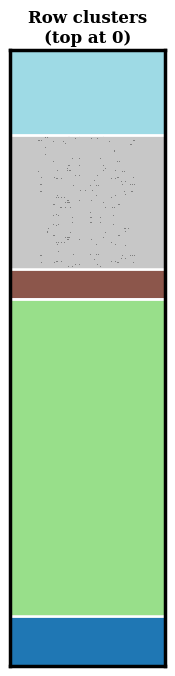

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Rebuild the pieces

# binary_mat is (union_mat_ext >= 0.6).astype(int)
# row_link_bin, row_leaves_bin, row_cluster_labels (from earlier block) must be defined

# row_leaves_bin: dendrogram order BEFORE flipping
# In the final figure, you did np.flipud(...)
# So the display order (top row in the figure = first here) is:
display_order = np.flipud(row_leaves_bin)

# These are the receptor IDs in the order they actually APPEAR in your final heatmap
receptors_display = np.array(binary_mat.index)[display_order]

# Get the cluster label for each displayed row in order top→bottom
row_cluster_display = row_cluster_labels[display_order]

# 2. Find boundaries: where does the cluster ID change as we go down?
boundaries = np.where(np.diff(row_cluster_display) != 0)[0]  # indices where cluster switches
# we'll add +1 because diff marks the boundary between i and i+1
boundaries = boundaries + 1  

print("Row display order shape:", receptors_display.shape)
print("Cluster labels in display order (top→bottom) first 30:")
print(row_cluster_display[:400])
print("Boundary row indices (top→bottom):", boundaries)

# 3. Quick diagnostic heatmap of just the row cluster IDs so you can see blocks
plt.figure(figsize=(2,8))
plt.imshow(row_cluster_display.reshape(-1,1), aspect='auto', cmap='tab20')
for b in boundaries:
    plt.axhline(b-0.5, color='white', linewidth=2)
plt.yticks([])
plt.xticks([])
plt.title("Row clusters\n(top at 0)")
plt.show()


In [15]:
# binary_mat already defined
# cluster_labels already defined (fcluster on col_link, n_clusters=7)
# col_order already defined (leaves_list(col_link))

import numpy as np
import pandas as pd

col_leaves = col_order
ligands_in_order = np.array(binary_mat.columns)[col_leaves]
col_cluster_labels_ordered = cluster_labels[col_leaves]

col_summary = []
for cl in np.unique(col_cluster_labels_ordered):
    idx = np.where(col_cluster_labels_ordered == cl)[0]
    these_ligands = ligands_in_order[idx]

    submat = binary_mat[these_ligands]

    # coverage of each ligand = fraction of receptors predicted to bind it
    ligand_coverage = submat.mean(axis=0)

    mean_coverage = ligand_coverage.mean()      # avg % of receptors responding to ligands in this cluster
    max_coverage = ligand_coverage.max()        # most global ligand in this cluster
    top_ligand   = ligand_coverage.idxmax()     # InChIKey of that 'universal' ligand

    col_summary.append({
        "ligand_cluster": int(cl),
        "n_ligands": int(len(these_ligands)),
        "mean_receptor_coverage": float(mean_coverage),
        "max_receptor_coverage": float(max_coverage),
        "top_ligand_inchikey": str(top_ligand),
        "example_ligands": list(these_ligands[:5])
    })

col_summary


[{'ligand_cluster': 1,
  'n_ligands': 127,
  'mean_receptor_coverage': 0.08099507192085977,
  'max_receptor_coverage': 0.3648960739030023,
  'top_ligand_inchikey': 'PXRBWNLUQYZAAX-UHFFFAOYSA-N',
  'example_ligands': ['WLJVNTCWHIRURA-UHFFFAOYSA-N',
   'WNLRTRBMVRJNCN-UHFFFAOYSA-N',
   'JFCQEDHGNNZCLN-UHFFFAOYSA-N',
   'NTWSIWWJPQHFTO-UHFFFAOYSA-N',
   'RFMMMVDNIPUKGG-YFKPBYRVSA-N']},
 {'ligand_cluster': 2,
  'n_ligands': 116,
  'mean_receptor_coverage': 0.06922433702317432,
  'max_receptor_coverage': 0.14549653579676675,
  'top_ligand_inchikey': 'YZEFQPIMXZVPKP-UHFFFAOYSA-N',
  'example_ligands': ['FZOZFDAMVVEZSJ-UHFFFAOYSA-N',
   'KGWPHCDTOLQQEP-UHFFFAOYSA-N',
   'GOMAKLPNAAZVCJ-UHFFFAOYSA-N',
   'LIIALPBMIOVAHH-UHFFFAOYSA-N',
   'DLRJIFUOBPOJNS-UHFFFAOYSA-N']},
 {'ligand_cluster': 3,
  'n_ligands': 358,
  'mean_receptor_coverage': 0.03842233604706671,
  'max_receptor_coverage': 0.20554272517321015,
  'top_ligand_inchikey': 'XPTXKXKPWKNYKB-UHFFFAOYSA-N',
  'example_ligands': ['NHIMSNHO

### arcsine plots


Probabilities p ∈ [0,1] summary:
           N: 326482
         min: 0
         q05: 0.00506451
         q50: 0.0126718
         q95: 0.830391
         max: 1
        mean: 0.144757
         std: 0.262821
        skew: 1.93368
 kurt_excess: 2.34327

Transformed y = arcsin(√p) ∈ [0, π/2] summary:
           N: 326482
         min: 0
         q05: 0.0712256
         q50: 0.112808
         q95: 1.14633
         max: 1.5708
        mean: 0.291741
         std: 0.35006
        skew: 1.71252
 kurt_excess: 1.71557


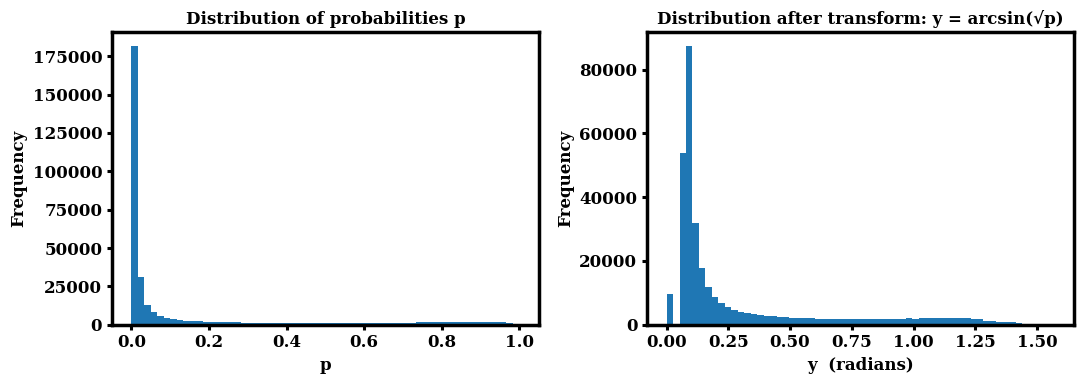

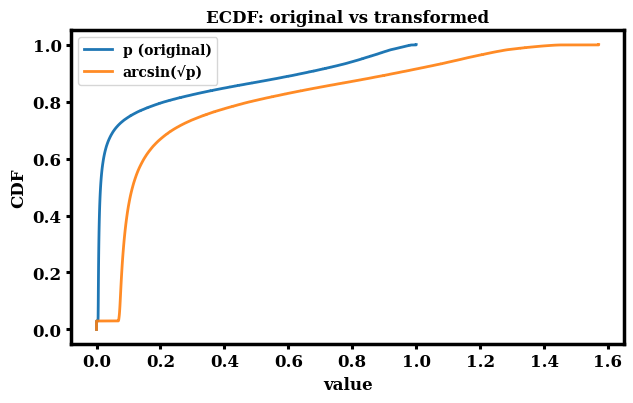

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ----- 1) Pull values -----
X = union_mat_ext.values.astype(float)
X = np.clip(np.nan_to_num(X, nan=0.0), 0.0, 1.0)
X_asin = np.arcsin(np.sqrt(X))   # in [0, π/2]

vals_p   = X.ravel()
vals_tr  = X_asin.ravel()
vals_p   = vals_p[~np.isnan(vals_p)]
vals_tr  = vals_tr[~np.isnan(vals_tr)]

# ----- 2) Quick summaries -----
def summarize(x, name):
    s = {
        "N": x.size,
        "min": float(np.min(x)),
        "q05": float(np.quantile(x, 0.05)),
        "q50": float(np.quantile(x, 0.50)),
        "q95": float(np.quantile(x, 0.95)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=1)),
        "skew": float(skew(x, bias=False)),
        "kurt_excess": float(kurtosis(x, fisher=True, bias=False)),
    }
    print(f"\n{name} summary:"); [print(f"{k:>12s}: {v:.6g}") for k,v in s.items()]

summarize(vals_p,  "Probabilities p ∈ [0,1]")
summarize(vals_tr, "Transformed y = arcsin(√p) ∈ [0, π/2]")

# ----- 3) Histograms (side-by-side) -----
fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].hist(vals_p, bins=60, edgecolor='none')
axes[0].set_title("Distribution of probabilities p")
axes[0].set_xlabel("p"); axes[0].set_ylabel("Frequency")

axes[1].hist(vals_tr, bins=60, edgecolor='none')
axes[1].set_title("Distribution after transform: y = arcsin(√p)")
axes[1].set_xlabel("y  (radians)"); axes[1].set_ylabel("Frequency")

plt.tight_layout(); plt.show()

# ----- 4) ECDF comparison (helps see tail behavior) -----
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, x.size+1) / x.size
    return x, y

xp, yp = ecdf(vals_p)
xt, yt = ecdf(vals_tr)

plt.figure(figsize=(6.5,4.2))
plt.step(xp, yp, where='post', label='p (original)')
plt.step(xt, yt, where='post', label='arcsin(√p)', alpha=0.9)
plt.xlabel("value"); plt.ylabel("CDF")
plt.title("ECDF: original vs transformed")
plt.legend(); plt.tight_layout(); plt.show()


### heatmaps tree order

In [16]:
ligands = union_mat_ext.columns.to_list()

clusters_of_ligands = {k: [] for k in range(1, n_clusters+1)}
for key, lab in zip(ligands, cluster_labels):
    clusters_of_ligands[int(lab)].append(key)
    
for k in range(1, n_clusters+1):
    print(f"{k}: {len(clusters_of_ligands[k])}")

1: 127
2: 116
3: 358
4: 11
5: 26
6: 53
7: 63


tree leaves: 433, mapped to seq_id: 415, to UP:*: 18
overlap rows (leaf_order) AFTER mapping: 433


/tmp/ipykernel_1430086/2704635117.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  brbg = mpl.cm.get_cmap('BrBG', n_clusters)


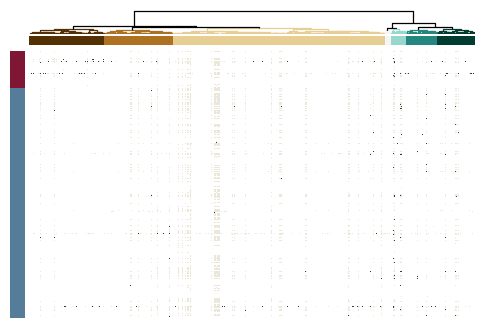

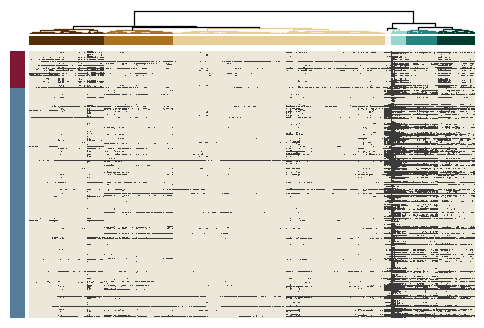

In [27]:
from io import StringIO
from Bio import Phylo

n_clusters = 7

brbg = mpl.cm.get_cmap('BrBG', n_clusters)
earthy = [to_hex(brbg(i)) for i in range(brbg.N)]
cluster_cmap = ListedColormap(earthy)

#########################################################################3
# from scipy.spatial.distance import pdist, squareform
# from scipy.cluster.hierarchy import linkage, leaves_list, fcluster 

# union_mat_ext = union_mat_ext.copy()

# # Base matrix in [0,1]; keep all zeros (biologically meaningful)
# X = union_mat_ext.values.astype(float)

# # Variance-stabilizing transform for proportions
# X_asin = np.arcsin(np.sqrt(X))

# # --- COLUMNS: Euclidean on arcsin–sqrt + Ward ---
# D_cols = pdist(X_asin.T, metric='euclidean')
# col_link = linkage(D_cols, method='ward', optimal_ordering=True)
# col_order = leaves_list(col_link)
############################################################################


union_mat_ext = union_mat_ext.copy()
col_link = linkage(pdist(union_mat_ext.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_link)

cluster_labels = fcluster(col_link, n_clusters, criterion='maxclust')
cluster_labels_ordered = cluster_labels[col_order]
cluster_stripe = (cluster_labels_ordered - 1).reshape(1, -1)
cluster2color = {lab: earthy[(lab-1) % len(earthy)] for lab in np.unique(cluster_labels)}

def make_link_color_func(linkage_matrix, leaf_clusters):
    def _color(node_id):
        if node_id < len(leaf_clusters):              # leaf
            return cluster2color[leaf_clusters[node_id]]
        left, right = (int(x) for x in linkage_matrix[node_id - len(leaf_clusters), :2])
        c_left, c_right = _color(left), _color(right)
        return c_left if c_left == c_right else 'black'
    return _color

link_cf = make_link_color_func(col_link, cluster_labels)

# -----------------------------------------------------------------------
# NEW: Replace row_order with the order from the phylogenetic tree
# -----------------------------------------------------------------------

newick_string = open("../../../../Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree").readline().strip()
tree = Phylo.read(StringIO(newick_string), "newick")


# If your tree leaves are "seq_id" already, this just works.
# If your tree leaves are UniProt IDs instead, uncomment the mapper below:
# for term in tree.get_terminals():
#     if term.name in uniprot2seq:
#         term.name = uniprot2seq[term.name]

# --- normalize tree leaf names to seq_id via UniProt -> seq_id map ---
def normalize_to_uniprot(name: str) -> str:
    tok = name.strip()
    if '.' in tok and tok.split('.', 1)[0].isdigit():  # "9606.Q8NH54" -> "Q8NH54"
        tok = tok.split('.', 1)[1]
    if '|' in tok:                                     # "sp|Q8NH54|..." -> "Q8NH54"
        parts = tok.split('|')
        if len(parts) >= 2:
            tok = parts[1]
    tok = tok.split('-', 1)[0]                         # drop isoform "-2"
    return tok

# rename tree leaves in-place to seq_id when possible
mapped_seq = 0
mapped_up  = 0
unmapped_examples = []

for term in tree.get_terminals():
    if not term.name:
        continue
    up = normalize_to_uniprot(term.name)
    if up in uniprot2seq:
        term.name = uniprot2seq[up]           # seq_id present in experimental data
        mapped_seq += 1
    else:
        term.name = f"UP:{up}"                # reference-only rows in exp_mat_ext
        mapped_up  += 1
        

print(f"tree leaves: {len(list(tree.get_terminals()))}, mapped to seq_id: {mapped_seq}, to UP:*: {mapped_up}")


leaf_order_all = [t.name for t in tree.get_terminals()]
leaf_order = [name for name in leaf_order_all if name in exp_mat_ext.index]

print("overlap rows (leaf_order) AFTER mapping:", len(leaf_order))  # should be 433 now
assert len(leaf_order) == len(exp_mat_ext.index) == 433, "Some tree leaves still not matched to matrix rows."

# Apply row order
exp_ord  = exp_mat_ext.loc[leaf_order, exp_mat_ext.columns[col_order]]
pred_ord = pred_mat_ext.loc[leaf_order, pred_mat_ext.columns[col_order]]

# --- make the row stripe (0 for class 1 = red, 1 for class 2 = blue) ---
class_map = (
    exp_human[['seq_id', 'Class']]
    .drop_duplicates()
    .set_index('seq_id')['Class']
    .str.lower().str.strip()
)

# fu['seq_id'] = (
#     fu['seq_id']
#     .astype(str)
#     .str.strip()
# )
fu_series = fu.set_index('seq_id')['Class']
class_map = class_map.combine_first(fu_series)

row_classes = (class_map.reindex(exp_ord.index)
                        .map({'class 1': 0, 'class 2': 1})
                        .fillna(2)
                        .astype(int)
                        .values.reshape(-1,1))

row_cmap = ListedColormap(['#7f1734', '#557c99'])



# Heat cmap (unchanged)
heat_cmap = ListedColormap(["#ece8d9", "#3b3b3b"])
heat_cmap.set_bad(color='white')

####################### COLORS PROBS ##########################
# from matplotlib.colors import LinearSegmentedColormap, Normalize

# # same colors you used before, but continuous (light → dark)
# heat_cmap = LinearSegmentedColormap.from_list("binary_to_cont",
#                                               ["#ece8d9", "#3b3b3b"])
# heat_cmap.set_bad("white")  # keep NaNs white
# heat_norm = Normalize(vmin=0.0, vmax=1.0) 
#############################################################



# def add_legends(fig, n_clusters, cluster_colors, row_cmap, heat_cmap, show_missing=True):    
#     handles = [
#         Patch(facecolor=heat_cmap(1), label='Active (1)'),
#         Patch(facecolor=heat_cmap(0), label='Inactive (0)'),
#     ]
#     if show_missing:
#         handles.append(Patch(facecolor='white', edgecolor='black', label='Missing'))
#     handles += [
#         Patch(facecolor=row_cmap(0), label='Class 1'),
#         Patch(facecolor=row_cmap(1), label='Class 2'),
#     ]
#     for lab, col in enumerate(cluster_colors, 1):
#         handles.append(Patch(facecolor=col, label=f'Cluster {lab}'))
#     fig.legend(handles=handles,
#                loc='center left', bbox_to_anchor=(1.02, 0.5),
#                frameon=False, fontsize=9)

def plot_pair(data_matrix, title, outdir='./Figures', dpi=300):
    """Plot single panel with dendrogram, enlarged column stripe, row stripe, heatmap."""
    fig = plt.figure(figsize=(6, 4))
    stripe_thickness = 0.3
    gs = gridspec.GridSpec(4, 2,
                           height_ratios=[0.8, stripe_thickness, 0.05, 9.0],
                           width_ratios=[stripe_thickness, 9.0],
                           hspace=0.03, wspace=0.02)    

    # column dendrogram (unchanged)
    ax_d = fig.add_subplot(gs[0,1])
    dendrogram(col_link, ax=ax_d, no_labels=True, color_threshold=0, link_color_func=link_cf)
    for coll in ax_d.collections:
        if isinstance(coll, mpl.collections.LineCollection):
            coll.set_linewidth(0.9)
            coll.set_alpha(1.0)
    ax_d.axis('off')

    # enlarged column stripe (unchanged)
    ax_colstripe = fig.add_subplot(gs[1,1])
    ax_colstripe.imshow(cluster_stripe, aspect='auto', cmap=cluster_cmap)
    ax_colstripe.axis('off')

    # NEW: row stripe already respects phylo order via row_classes
    ax_rowstripe = fig.add_subplot(gs[3,0])
    ax_rowstripe.imshow(row_classes, aspect='auto', cmap=row_cmap)
    ax_rowstripe.axis('off')

    # heatmap
    ax_h = fig.add_subplot(gs[3,1])
    ax_h.imshow(data_matrix, aspect='auto', interpolation='none', cmap=heat_cmap)
    ax_h.axis('off')

    #fig.suptitle(title, y=0.93, fontsize=12, fontweight='bold')
    #add_legends(fig, n_clusters, earthy, row_cmap, heat_cmap, show_missing=False)
    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    fig.savefig(Path(outdir) / fname, dpi=dpi, bbox_inches='tight', transparent=True, format='png')
    plt.show()
    plt.close(fig)
    

Path('./Figures').mkdir(exist_ok=True)
plot_pair(np.ma.masked_invalid(exp_ord.values), f'Experimental (Tree Order) (k={n_clusters})', outdir='./Figures')
plot_pair(pred_ord.values, f'Predicted (Tree Order) 0.6 pred (k={n_clusters})', outdir='./Figures')

In [18]:
from matplotlib.patches import Patch

def build_legend_handles(n_clusters, cluster_cmap, row_cmap, heat_cmap, show_missing=False):
    # heatmap states
    handles = [
        Patch(facecolor=heat_cmap(1.0), label='Active (1)'),
        Patch(facecolor=heat_cmap(0.0), label='Inactive (0)'),
    ]
    if show_missing:
        handles.append(Patch(facecolor='white', edgecolor='0.5', label='Missing'))

    # row classes
    handles += [
        Patch(facecolor=row_cmap(0.0), label='Class 1'),
        Patch(facecolor=row_cmap(1.0), label='Class 2'),
    ]

    # column clusters (BrBG)
    if getattr(cluster_cmap, "colors", None) is not None:
        cols = cluster_cmap.colors[:n_clusters]
    else:
        # sample across the map if colors attribute missing
        denom = max(n_clusters - 1, 1)
        cols = [cluster_cmap(i/denom) for i in range(n_clusters)]
    handles += [Patch(facecolor=cols[i], label=f'Cluster {i+1}') for i in range(n_clusters)]

    return handles


In [64]:
import matplotlib.pyplot as plt
from math import ceil

def save_legend(handles, path, ncol=1, fontsize=9, title=None, dpi=300):
    # size scales with items & columns
    h = 0.38 * ceil(len(handles) / ncol) + 0.4
    w = 2.2 * ncol
    fig = plt.figure(figsize=(w, h))
    fig.legend(
        handles=handles,
        loc='center', frameon=False, ncol=ncol,
        title=title, fontsize=fontsize, title_fontsize=fontsize
    )
    fig.savefig(path, bbox_inches='tight', dpi=dpi, transparent=True)
    plt.close(fig)

# Example:
handles = build_legend_handles(n_clusters, cluster_cmap, row_cmap, heat_cmap, show_missing=False)
save_legend(handles, './Figures/legend.svg', ncol=1, fontsize=9)

### enrichment

In [19]:
pred_ord

,WLJVNTCWHIRURA-UHFFFAOYSA-N,WNLRTRBMVRJNCN-UHFFFAOYSA-N,JFCQEDHGNNZCLN-UHFFFAOYSA-N,NTWSIWWJPQHFTO-UHFFFAOYSA-N,RFMMMVDNIPUKGG-YFKPBYRVSA-N,KDYFGRWQOYBRFD-UHFFFAOYSA-N,KPGXRSRHYNQIFN-UHFFFAOYSA-N,QTBSBXVTEAMEQO-UHFFFAOYSA-N,XBDQKXXYIPTUBI-UHFFFAOYSA-N,WLAMNBDJUVNPJU-UHFFFAOYSA-N,...,QUKGYYKBILRGFE-UHFFFAOYSA-N,KMYWVDDIPVNLME-KQYNXXCUSA-N,XVFMGWDSJLBXDZ-UHFFFAOYSA-O,PXIKRTCSSLJURC-UHFFFAOYSA-N,ZQISRDCJNBUVMM-YFKPBYRVSA-N,DBZAKQWXICEWNW-UHFFFAOYSA-N,MCSCIFLXNFLCDV-UHFFFAOYSA-N,HNJBEVLQSNELDL-UHFFFAOYSA-N,OFQPKKGMNWASPN-UHFFFAOYSA-N,SKSFHXVDHVKIBN-UHFFFAOYSA-N
SEQ1400,0,0,0,1,0,0,1,1,1,1,...,0,1,1,0,0,0,0,0,0,0
SEQ0506,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
SEQ0086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SEQ0937,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
UP:Q8NGI1,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SEQ0033,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,1,1,1,1
SEQ1265,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
SEQ1077,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,1,0,0,0,1,1
SEQ0524,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
ligands = union_mat_ext.columns.to_list()

clusters_of_ligands = {k: [] for k in range(1, n_clusters+1)}
for key, lab in zip(ligands, cluster_labels):
    clusters_of_ligands[int(lab)].append(key)
    
for k in range(1, n_clusters+1):
    print(f"{k}: {len(clusters_of_ligands[k])}")

1: 127
2: 116
3: 358
4: 11
5: 26
6: 53
7: 63


In [21]:
# -----------------------------
# Inputs assumed to exist:
# pred_ord  (rows=seq_id, cols=InChIKey)  -- use your reordered columns
# cluster_labels_ordered (len == len(pred_ord.columns), values in {1..n_clusters})
# earthy (list of hex colors), n_clusters
# -----------------------------
assert len(pred_ord.columns) == len(cluster_labels_ordered), "Columns vs cluster labels mismatch."

# 1) ligand -> cluster assignment
inchis = list(pred_ord.columns)
assign_df = pd.DataFrame({"InChIKey": inchis, "ClusterID": cluster_labels_ordered.astype(int)})
cluster_sizes = assign_df["ClusterID"].value_counts().sort_index()
clusters_id = np.sort(cluster_sizes.index)        # array([1,2,...,k])
C = clusters_id.size

# 2) ligand × tag matrix
odors_path = "../../../predictions/aggregated/ASR_Predictions_RefTree/inchi_odors.csv"
odors = pd.read_csv(odors_path)

od = odors[['InChIKey', 'Odors']].dropna(subset=['InChIKey']).copy()
od = od[od['InChIKey'].isin(inchis)]
od = od.dropna(subset=['Odors']).copy()
od['Odors'] = od['Odors'].astype(str).str.lower()
od_expl = od.assign(tag=od['Odors'].str.split(',')).explode('tag')
od_expl['tag'] = od_expl['tag'].str.strip()
od_expl = od_expl[od_expl['tag'] != ""].drop_duplicates()

all_tags = sorted(od_expl['tag'].unique().tolist())
T = len(all_tags)
N = len(inchis)

lig_index = {k: i for i, k in enumerate(inchis)}
tag_index = {t: j for j, t in enumerate(all_tags)}

tag_matrix = np.zeros((N, T), dtype=np.uint8)
for _, r in od_expl.iterrows():
    i = lig_index.get(r['InChIKey'])
    j = tag_index.get(r['tag'])
    if i is not None and j is not None:
        tag_matrix[i, j] = 1

# 3) permutation test
labels = assign_df["ClusterID"].values
cluster_mat = (labels[:, None] == clusters_id).astype(np.uint8)
obs_counts  = cluster_mat.T @ tag_matrix        # (C × T)

n_perm = 99999
rng = np.random.default_rng(42)

ge_than = np.zeros_like(obs_counts, dtype=np.uint32) 

sum_cnt = np.zeros_like(obs_counts, dtype=np.uint32)

for p in range(n_perm):
    perm_labels = rng.permutation(labels)
    perm_mat    = (perm_labels[:, None] == clusters_id).astype(np.uint8)
    perm_counts = perm_mat.T @ tag_matrix

    ge_than += (perm_counts >= obs_counts)
    sum_cnt += perm_counts
    
    if (p + 1) % 1000 == 0:
        print(f"{p+1:6d} permutations done")

expected = sum_cnt / n_perm
pvals    = (ge_than + 1) / (n_perm + 1)           # add-one smoothing
obs_exp  = obs_counts / np.maximum(expected, 1e-9)

# 4) full results DataFrame 
global_tag_counts = tag_matrix.sum(axis=0)        # total frequency of each tag across ALL ligands

cluster_color_map = {c: earthy[(c-1) % len(earthy)] for c in clusters_id}
records = []
for c_idx, c in enumerate(clusters_id):
    for j, tag in enumerate(all_tags):
        records.append({
            "ClusterID": int(c),
            "ClusterName": f"Cluster {c}",
            "ClusterColor": cluster_color_map[c],
            "Tag": tag,
            "Observed": int(obs_counts[c_idx, j]),
            "TotalFrequency": int(global_tag_counts[j]),
            "Expected": float(expected[c_idx, j]),
            "Obs/Exp": float(obs_exp[c_idx, j]),
            "p-value": float(pvals[c_idx, j]),
        })
enrichment_df = pd.DataFrame(records).sort_values(
    ["ClusterID", "p-value", "Obs/Exp"], ascending=[True, True, False]
).reset_index(drop=True)

# 5) filter to enriched only (p <= cutoff and Obs/Exp > 1)
PVALUE_CUTOFF = 0.05
enrichment_sig_df = (
    enrichment_df.query("`p-value` <= @PVALUE_CUTOFF and `Obs/Exp` > 1")
                 .copy()
                 .sort_values(["ClusterID","p-value","Obs/Exp"], ascending=[True,True,False])
                 .reset_index(drop=True)
)

# 6) per-cluster summary of enriched perceptions (list of tags)
# (sorted by p then Obs/Exp; keep all significant tags)
cluster_summary = []
for cid in clusters_id:
    dfc = enrichment_sig_df[enrichment_sig_df["ClusterID"] == cid]
    dfc = dfc.sort_values(["p-value","Obs/Exp"], ascending=[True,False])
    cluster_summary.append({
        "ClusterID": cid,
        "ClusterName": f"Cluster {cid}",
        "ClusterColor": cluster_color_map[cid],
        "n_enriched_tags": int(dfc.shape[0]),
        "EnrichedTags": dfc["Tag"].tolist()
    })
cluster_summary_df = pd.DataFrame(cluster_summary)

# (optional) save to disk
# enrichment_df.to_csv("enrichment_full.csv", index=False)
# enrichment_sig_df.to_csv("enrichment_significant.csv", index=False)
# cluster_summary_df.to_csv("enrichment_cluster_summary.csv", index=False)

# Handy peek
print("enrichment_df:", enrichment_df.shape, " | enrichment_sig_df:", enrichment_sig_df.shape)

  1000 permutations done
  2000 permutations done
  3000 permutations done
  4000 permutations done
  5000 permutations done
  6000 permutations done
  7000 permutations done
  8000 permutations done
  9000 permutations done
 10000 permutations done
 11000 permutations done
 12000 permutations done
 13000 permutations done
 14000 permutations done
 15000 permutations done
 16000 permutations done
 17000 permutations done
 18000 permutations done
 19000 permutations done
 20000 permutations done
 21000 permutations done
 22000 permutations done
 23000 permutations done
 24000 permutations done
 25000 permutations done
 26000 permutations done
 27000 permutations done
 28000 permutations done
 29000 permutations done
 30000 permutations done
 31000 permutations done
 32000 permutations done
 33000 permutations done
 34000 permutations done
 35000 permutations done
 36000 permutations done
 37000 permutations done
 38000 permutations done
 39000 permutations done
 40000 permutations done


In [22]:
enrichment_df

,ClusterID,ClusterName,ClusterColor,Tag,Observed,TotalFrequency,Expected,Obs/Exp,p-value
0,1,Cluster 1,#543005,acidic,9,9,1.513875,5.945008,0.00001
1,1,Cluster 1,#543005,sour,16,18,3.025190,5.288924,0.00001
2,1,Cluster 1,#543005,odorless,11,14,2.357154,4.666645,0.00001
3,1,Cluster 1,#543005,dairy,15,26,4.380194,3.424506,0.00002
4,1,Cluster 1,#543005,cheesy,19,42,7.064481,2.689511,0.00002
...,...,...,...,...,...,...,...,...,...
1045,7,Cluster 7,#003c30,tobacco,0,11,0.920329,0.000000,1.00000
1046,7,Cluster 7,#003c30,tomato,0,5,0.416834,0.000000,1.00000
1047,7,Cluster 7,#003c30,violet,0,9,0.750748,0.000000,1.00000
1048,7,Cluster 7,#003c30,weedy,0,5,0.418254,0.000000,1.00000


In [23]:
enri = enrichment_sig_df.loc[enrichment_sig_df["p-value"] < 0.01]

In [24]:
enri

,ClusterID,ClusterName,ClusterColor,Tag,Observed,TotalFrequency,Expected,Obs/Exp,p-value
0,1,Cluster 1,#543005,acidic,9,9,1.513875,5.945008,0.00001
1,1,Cluster 1,#543005,sour,16,18,3.025190,5.288924,0.00001
2,1,Cluster 1,#543005,odorless,11,14,2.357154,4.666645,0.00001
3,1,Cluster 1,#543005,dairy,15,26,4.380194,3.424506,0.00002
4,1,Cluster 1,#543005,cheesy,19,42,7.064481,2.689511,0.00002
5,1,Cluster 1,#543005,coconut,12,24,4.032030,2.976168,0.00010
6,1,Cluster 1,#543005,creamy,17,43,7.236182,2.349305,0.00027
7,1,Cluster 1,#543005,milky,8,13,2.190652,3.651881,0.00040
8,1,Cluster 1,#543005,pineapple,13,30,5.044390,2.577120,0.00051
9,1,Cluster 1,#543005,fatty,29,108,18.174132,1.595675,0.00322


In [25]:
#save enri to csv
enri.to_csv("final_enrichment.csv", index=False)

In [26]:
top_tags_per_cluster = []

for cid in sorted(enri["ClusterID"].unique()):
    dfc = (
        enri[enri["ClusterID"] == cid]
        .sort_values(["p-value", "Obs/Exp"], ascending=[True, False])
        .head(5)  # take the 5 strongest tags per cluster
        .copy()
    )
    # store a clean view
    top_tags_per_cluster.append({
        "ClusterID": cid,
        "n_ligands_in_cluster": int(
            col_summary[[c["ligand_cluster"] for c in col_summary].index(cid)]["n_ligands"]
        ),
        "tags": [
            {
                "tag": row["Tag"],
                "obs": int(row["Observed"]),
                "exp": float(row["Expected"]),
                "fold": float(row["Obs/Exp"]),
                "p": float(row["p-value"])
            }
            for _, row in dfc.iterrows()
        ]
    })

top_tags_per_cluster

[{'ClusterID': 1,
  'n_ligands_in_cluster': 127,
  'tags': [{'tag': 'acidic',
    'obs': 9,
    'exp': 1.5138751387513876,
    'fold': 5.945008124925686,
    'p': 1e-05},
   {'tag': 'sour',
    'obs': 16,
    'exp': 3.025190251902519,
    'fold': 5.288923561067844,
    'p': 1e-05},
   {'tag': 'odorless',
    'obs': 11,
    'exp': 2.3571535715357155,
    'fold': 4.6666454544297515,
    'p': 1e-05},
   {'tag': 'dairy',
    'obs': 15,
    'exp': 4.380193801938019,
    'fold': 3.4245060100681486,
    'p': 2e-05},
   {'tag': 'cheesy',
    'obs': 19,
    'exp': 7.064480644806448,
    'fold': 2.689511225990564,
    'p': 2e-05}]},
 {'ClusterID': 2,
  'n_ligands_in_cluster': 116,
  'tags': [{'tag': 'phenolic',
    'obs': 22,
    'exp': 6.148771487714877,
    'fold': 3.577950496933503,
    'p': 1e-05},
   {'tag': 'spicy',
    'obs': 25,
    'exp': 8.620126201262012,
    'fold': 2.9001895582851125,
    'p': 1e-05},
   {'tag': 'vanilla',
    'obs': 9,
    'exp': 2.6109661096610965,
    'fold': 3.4

Number of unique tags: 26
Tags: ['acidic', 'sour', 'odorless', 'dairy', 'cheesy', 'phenolic', 'spicy', 'vanilla', 'nutty', 'bready', 'ethereal', 'oily', 'alcoholic', 'garlic', 'green', 'cucumber', 'fatty', 'aldehydic', 'melon', 'citrus', 'tea', 'amber', 'sweet', 'plum', 'floral', 'balsamic']
Colors: ['#543005', '#ae7121', '#e7cf94', '#f5f5f5', '#98d7cd', '#24877f', '#003c30']
Processing cluster 1
Cluster 1 → color index 0 → #543005
Processing cluster 2
Cluster 2 → color index 1 → #ae7121
Processing cluster 3
Cluster 3 → color index 2 → #e7cf94
Processing cluster 4
Cluster 4 → color index 3 → #f5f5f5
Processing cluster 5
Cluster 5 → color index 4 → #98d7cd
Processing cluster 7
Cluster 7 → color index 6 → #003c30


/tmp/ipykernel_1430086/727371173.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  brbg = mpl.cm.get_cmap('BrBG', 7)


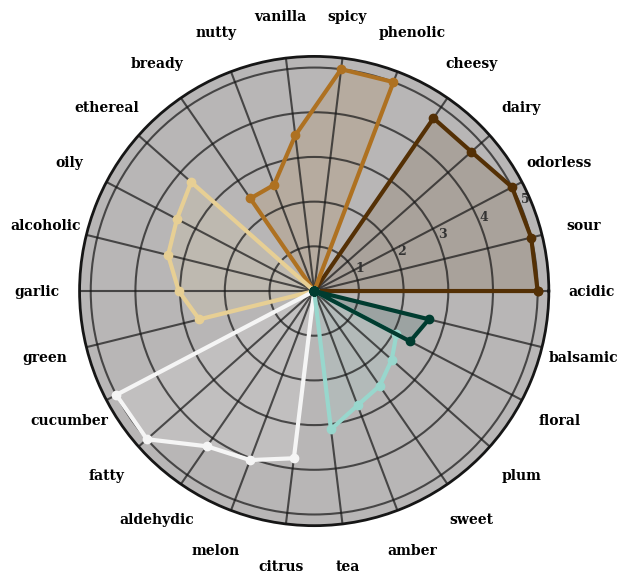

In [30]:
def plot_unified_spider(top_tags_per_cluster):
    # Collect all unique tags across all clusters
    all_tags = []
    for entry in top_tags_per_cluster:
        for tag in entry["tags"]:
            if tag["tag"] not in all_tags:
                all_tags.append(tag["tag"])
    
    print(f"Number of unique tags: {len(all_tags)}")
    print(f"Tags: {all_tags}")
    
    # Create a matrix: rows = clusters, cols = tags
    n_clusters = len(top_tags_per_cluster)
    n_tags = len(all_tags)
    
    fig = plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)
    
    # Set gray background to make white lines visible
    ax.set_facecolor("#B8B6B6")
    
    # Make grid more visible with darker lines
    ax.grid(True, color="#161616", linewidth=1.5, linestyle='-', alpha=0.7)
    ax.spines['polar'].set_color('#161616')
    ax.spines['polar'].set_linewidth(2)
    
    angles = np.linspace(0, 2*np.pi, n_tags, endpoint=False)
    angles = np.concatenate([angles, angles[:1]])
    
    # Use your exact colormap from the heatmap code
    brbg = mpl.cm.get_cmap('BrBG', 7)
    earthy = [to_hex(brbg(i)) for i in range(brbg.N)]
    
    print(f"Colors: {earthy}")
    
    for idx, entry in enumerate(top_tags_per_cluster):
        cid = entry["ClusterID"]
        print(f"Processing cluster {cid}")
        
        # Build -log10(p-value) for this cluster
        significance_values = []
        for tag in all_tags:
            # Find if this tag exists in this cluster
            matching = [t for t in entry["tags"] if t["tag"] == tag]
            if matching:
                # Use -log10(p-value) so higher values = more significant
                pval = matching[0]["p"]
                if pval > 0:
                    significance_values.append(-np.log10(pval))
                else:
                    significance_values.append(10)  # cap very small p-values
            else:
                significance_values.append(0)
        
        # Close the polygon
        significance_values = np.array(significance_values)
        significance_values = np.concatenate([significance_values, [significance_values[0]]])
        
        # Map cluster ID (1-7) to color index (0-6)
        # Cluster 1 → earthy[0] (brown), Cluster 2 → earthy[1], etc.
        color_idx = cid - 1
        if 0 <= color_idx < len(earthy):
            color = earthy[color_idx]
        else:
            color = earthy[0]  # fallback
        
        print(f"Cluster {cid} → color index {color_idx} → {color}")
        
        ax.plot(angles, significance_values, linewidth=3, label=f"Cluster {cid}", 
                color=color, marker='o', markersize=6)
        ax.fill(angles, significance_values, alpha=0.15, color=color)
    
    # Set the labels for each spoke
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(all_tags, fontsize=10)
    
    # Adjust label position to make them more visible
    ax.tick_params(pad=20)
    
    ax.set_title("", 
                 fontsize=16, pad=30)
    ax.set_rlabel_position(22.5)
    ax.tick_params(axis='y', labelsize=9, colors='#333333')
    #ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.1), fontsize=10)
    
    plt.tight_layout()
    plt.savefig("spider_enriched.png", bbox_inches='tight', format='png', transparent=True, dpi=300)
    plt.show()

plot_unified_spider(top_tags_per_cluster)

In [111]:
#enrichment_df.loc[enrichment_df["p-value"] < 0.01].to_csv("enrichment_7_clusters.csv", index=False)
enrichment_df.loc[enrichment_df["p-value"] < 0.01]

,ClusterID,ClusterName,ClusterColor,Tag,Observed,TotalFrequency,Expected,Obs/Exp,p-value
0,1,Cluster 1,#543005,sour,16,18,2.459495,6.505402,0.00001
1,1,Cluster 1,#543005,acidic,8,9,1.229862,6.504793,0.00001
2,1,Cluster 1,#543005,odorless,12,14,1.906889,6.292972,0.00001
3,1,Cluster 1,#543005,cheesy,20,42,5.736127,3.486673,0.00001
4,1,Cluster 1,#543005,dairy,12,26,3.552616,3.377793,0.00004
5,1,Cluster 1,#543005,waxy,24,96,13.097151,1.832460,0.00106
6,1,Cluster 1,#543005,fatty,26,108,14.742217,1.763642,0.00122
7,1,Cluster 1,#543005,milky,6,13,1.776728,3.376995,0.00453
150,2,Cluster 2,#ae7121,phenolic,23,40,7.913399,2.906463,0.00001
151,2,Cluster 2,#ae7121,spicy,24,56,11.082331,2.165609,0.00003


### categories of smiles

In [86]:
class_map

seq_id
SEQ0000    class 2
SEQ0003    class 2
SEQ0004    class 2
SEQ0005    class 2
SEQ0006    class 2
            ...   
SEQ1397    class 1
SEQ1398    class 1
SEQ1399    class 1
SEQ1400    class 1
SEQ1401    class 1
Name: Class, Length: 1205, dtype: object

In [61]:
union_mat_ext

,XMGQYMWWDOXHJM-SNVBAGLBSA-N,ULDHMXUKGWMISQ-VIFPVBQESA-N,NOOLISFMXDJSKH-AEJSXWLSSA-N,LRHPLDYGYMQRHN-UHFFFAOYSA-N,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,LQZZUXJYWNFBMV-UHFFFAOYSA-N,BDERNNFJNOPAEC-UHFFFAOYSA-N,FJPGAMCQJNLTJC-UHFFFAOYSA-N,LCZUOKDVTBMCMX-UHFFFAOYSA-N,QPRQEDXDYOZYLA-UHFFFAOYSA-N,...,NKBWMBRPILTCRD-UHFFFAOYSA-N,JZBCTZLGKSYRSF-UHFFFAOYSA-N,CHCKBDDEJDVRSJ-UHFFFAOYSA-N,ZBYPSGBBPAPHDG-UHFFFAOYSA-N,FYGUSUBEMUKACF-UHFFFAOYSA-N,LXXNWCFBZHKFPT-UHFFFAOYSA-N,XSAYZAUNJMRRIR-UHFFFAOYSA-N,JLPUXFOGCDVKGO-TUAOUCFPSA-N,JDLKFOPOAOFWQN-UHFFFAOYSA-N,RTUMCNDCAVLXEP-UHFFFAOYSA-N
SEQ0005,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SEQ0011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
SEQ0013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
SEQ0022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
SEQ0029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UP:Q8NGY7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
UP:Q8NH95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
UP:Q8NHA6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
UP:Q96R84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
ligands = union_mat_ext.columns.to_list()

clusters_of_ligands = {k: [] for k in range(1, n_clusters+1)}
for key, lab in zip(ligands, cluster_labels):
    clusters_of_ligands[int(lab)].append(key)
    
for k in range(1, n_clusters+1):
    print(f"{k}: {len(clusters_of_ligands[k])}")

1: 127
2: 116
3: 358
4: 11
5: 26
6: 53
7: 63


In [52]:
#convert clusters_of_ligands to dataframe and save as csv
clusters_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in clusters_of_ligands.items()]))
#clusters_df.to_csv('../04.Figures/ligand_clusters.csv', index=False)
clusters_df

,1,2,3,4,5,6,7
0,AKGGYBADQZYZPD-UHFFFAOYSA-N,AEMFNILZOJDQLW-QAGGRKNESA-N,CLGFIVUFZRGQRP-UHFFFAOYSA-N,ACZGCWSMSTYWDQ-UHFFFAOYSA-N,AMXYRHBJZOVHOL-DYWGDJMRSA-N,AOGQPLXWSUTHQB-UHFFFAOYSA-N,ABRIMXGLNHCLIP-UHFFFAOYSA-N
1,AXORVIZLPOGIRG-UHFFFAOYSA-N,BGTBFNDXYDYBEY-FNORWQNLSA-N,CRDAMVZIKSXKFV-YFVJMOTDSA-N,AIVVNNYXOSPRCW-UHFFFAOYSA-N,BDJRBEYXGGNYIS-UHFFFAOYSA-N,AZOCECCLWFDTAP-RKDXNWHRSA-N,ABRIMXGLNHCLIP-VURMDHGXSA-N
2,CBJPZHSWLMJQRI-UHFFFAOYSA-N,BJIOGJUNALELMI-ONEGZZNKSA-N,DFJMIMVMOIFPQG-UHFFFAOYSA-N,BOPPSUHPZARXTH-UHFFFAOYSA-N,BYEVBITUADOIGY-UHFFFAOYSA-N,AZOCECCLWFDTAP-UHFFFAOYSA-N,ALHUZKCOMYUFRB-HNNXBMFYSA-N
3,CCRCUPLGCSFEDV-BQYQJAHWSA-N,BSAIUMLZVGUGKX-BQYQJAHWSA-N,DTUQWGWMVIHBKE-UHFFFAOYSA-N,BSAIUMLZVGUGKX-FPLPWBNLSA-N,CCPPLLJZDQAOHD-FLIBITNWSA-N,BAVONGHXFVOKBV-UHFFFAOYSA-N,ALHUZKCOMYUFRB-OAHLLOKOSA-N
4,CHCKBDDEJDVRSJ-UHFFFAOYSA-N,CRIGTVCBMUKRSL-FNORWQNLSA-N,FINOPSACFXSAKB-UHFFFAOYSA-N,BZLYOWSSNHNYKW-UHFFFAOYSA-N,CETWDUZRCINIHU-UHFFFAOYSA-N,BAVONGHXFVOKBV-YHMJZVADSA-N,ALHUZKCOMYUFRB-UHFFFAOYSA-N
...,...,...,...,...,...,...,...
227,NaN,NaN,NaN,NaN,NaN,NaN,ZSBOMYJPSRFZAL-JLHYYAGUSA-N
228,NaN,NaN,NaN,NaN,NaN,NaN,ZSIAUFGUXNUGDI-UHFFFAOYSA-N
229,NaN,NaN,NaN,NaN,NaN,NaN,ZWEHNKRNPOVVGH-UHFFFAOYSA-N
230,NaN,NaN,NaN,NaN,NaN,NaN,ZXEKIIBDNHEJCQ-UHFFFAOYSA-N


Cophenetic correlation (rows only, n=433):
  Euclidean          : 0.117
  arcsin–sqrt+Euc    : 0.131


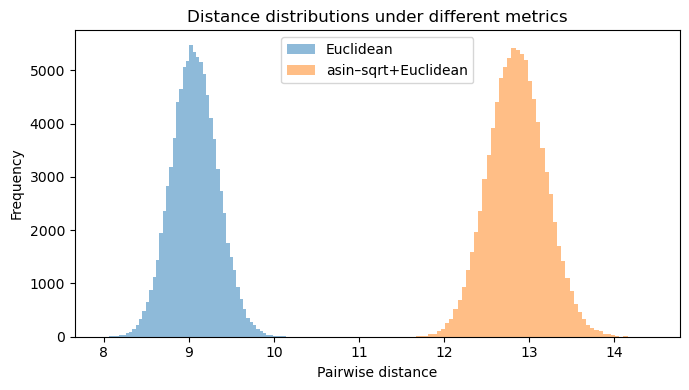

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, cophenet
import matplotlib.pyplot as plt

# --- Simulate probability matrix like yours ---
# alpha,beta fitted earlier: 0.32, 1.43  -> right-skewed
np.random.seed(0)
n_rows, n_cols = 433, 754
X = np.random.beta(0.32, 1.43, size=(n_rows, n_cols))

# a few near-zeros as in real data
X[X < 0.01] = 0.0

# --- (1) Euclidean + Ward ---
D_euc = pdist(X, metric='euclidean')
Z_euc = linkage(D_euc, method='ward', optimal_ordering=True)
c_euc, _ = cophenet(Z_euc, D_euc)

# --- (3) arcsin–sqrt + Euclidean + Ward ---
X_asin = np.arcsin(np.sqrt(X))
D_asin = pdist(X_asin, metric='euclidean')
Z_asin = linkage(D_asin, method='ward', optimal_ordering=True)
c_asin, _ = cophenet(Z_asin, D_asin)

print(f"Cophenetic correlation (rows only, n={n_rows}):")
print(f"  Euclidean          : {c_euc:.3f}")
print(f"  arcsin–sqrt+Euc    : {c_asin:.3f}")

# Optional: show pairwise distance distributions
plt.figure(figsize=(7,4))
plt.hist(D_euc, bins=60, alpha=0.5, label='Euclidean')
plt.hist(D_asin, bins=60, alpha=0.5, label='asin–sqrt+Euclidean')
plt.legend(); plt.xlabel("Pairwise distance"); plt.ylabel("Frequency")
plt.title("Distance distributions under different metrics")
plt.tight_layout(); plt.show()


Using 582 ligands present in both embeddings and clusters.


/home/izirdeli/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


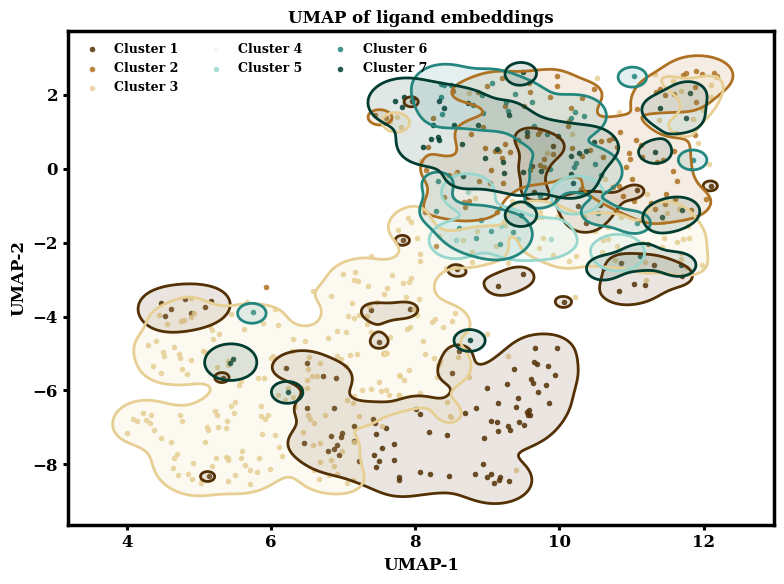

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# pip install umap-learn if needed
import umap


# --- inputs you already have in memory ---
# pred_ord: receptors × ligands (columns are InChIKeys)
# cluster_labels_ordered: len == len(pred_ord.columns), values 1..n_clusters
# earthy: list of BrBG hex colors of length n_clusters
# clusters_id: e.g. np.array([1,2,3,4,5,6,7])
# enrichment_df with columns ["Cluster","Tag","Observed","TotalFrequency","Expected","Obs/Exp","p-value"]
# PVALUE_CUTOFF

# 1) cluster labels by InChIKey (from your heatmap order)
assign_df = pd.DataFrame({
    "InChIKey": list(pred_ord.columns),
    "Cluster":  cluster_labels_ordered
})

# 2) load your ligand embeddings
emb_path = "../../../../Model/Embeddings/molecules/molformer_smiles_embeddings.pt"  # TODO: .pt file, update loading code
emb_df = pd.read_csv(emb_path)
assert "InChIKey" in emb_df.columns, "ligand_embeddings.csv must have an 'InChIKey' column"

# numeric feature columns in the CSV (exclude id/known columns)
exclude_cols = {"InChIKey", "Cluster", "UMAP1", "UMAP2"}
feat_cols = [c for c in emb_df.columns
             if c not in exclude_cols and np.issubdtype(emb_df[c].dtype, np.number)]
assert len(feat_cols) > 0 or {"UMAP1","UMAP2"}.issubset(emb_df.columns), \
       "No numeric feature columns found (or UMAP1/UMAP2 missing)."

# 3) align to ligands we clustered
df = emb_df.merge(assign_df, on="InChIKey", how="inner")
print(f"Using {len(df)} ligands present in both embeddings and clusters.")

# 4) compute (or reuse) 2D embedding
if {"UMAP1","UMAP2"}.issubset(df.columns):
    emb = df[["UMAP1","UMAP2"]].to_numpy()
else:
    X = df[feat_cols].to_numpy(dtype=np.float32)
    reducer = umap.UMAP(n_neighbors=50, min_dist=0.50, metric="cosine", random_state=42)
    emb = reducer.fit_transform(X)
    df["UMAP1"], df["UMAP2"] = emb[:,0], emb[:,1]

# 5) color map (BrBG, same as heatmap)
CLUSTER2HEX = {cid: earthy[cid-1] for cid in clusters_id}
point_colors = df["Cluster"].map(CLUSTER2HEX)

# helper: top enriched tags per cluster (from enrichment_df)
def top_tags_for_cluster(c, k=5, pcut=0.01):
    label = f"Cluster {c}"
    sub = enrichment_df[(enrichment_df["ClusterID"] == label) &
                        (enrichment_df["p-value"] <= pcut)].copy()
    if sub.empty:
        return []
    sub = sub.sort_values(["p-value","Obs/Exp"], ascending=[True, False])
    return sub["Tag"].head(k).tolist()

cluster2tags = {c: top_tags_for_cluster(c, k=3, pcut=PVALUE_CUTOFF) for c in clusters_id}

# 6) plot
plt.figure(figsize=(8,6))
for c in clusters_id:
    m = df["Cluster"].eq(c).values
    plt.scatter(df.loc[m,"UMAP1"], df.loc[m,"UMAP2"],
                s=16, c=CLUSTER2HEX[c], label=f"Cluster {c}", alpha=0.85, linewidths=0)

# annotate cluster centroids with top tags
for c in clusters_id:
    m = df["Cluster"].eq(c).values
    if not m.any():
        continue
    cx, cy = df.loc[m,["UMAP1","UMAP2"]].mean()
    tags = cluster2tags.get(c, [])
    if tags:
        txt = ", ".join(tags)
        plt.text(cx, cy, txt, ha="center", va="center", fontsize=6,
                 bbox=dict(boxstyle="round,pad=0.15", fc="white",
                           ec=CLUSTER2HEX[c], lw=1, alpha=0.9))
        

##################################################################################
# --- smooth "lasso" blobs per cluster via blurred 2D histogram + contour ---
import numpy as np
from scipy.ndimage import gaussian_filter

ax = plt.gca()

# global grid bounds (pad a bit so blobs aren't clipped)
x = df["UMAP1"].to_numpy(); y = df["UMAP2"].to_numpy()
pad = 0.1
xmin, xmax = x.min()-pad*(x.max()-x.min()), x.max()+pad*(x.max()-x.min())
ymin, ymax = y.min()-pad*(y.max()-y.min()), y.max()+pad*(y.max()-y.min())

# grid resolution + smoothing/level controls (tune these 3)
NX, NY = 400, 400          # larger = smoother edges
SIGMA   = 10.0              # Gaussian blur (in grid pixels)
LEVEL_Q = 0.80             # fraction enclosed; 0.85–0.95 works nicely

for c in clusters_id:
    m = df["Cluster"].eq(c).values
    if not m.any():
        continue
    xc = df.loc[m, "UMAP1"].to_numpy()
    yc = df.loc[m, "UMAP2"].to_numpy()
    color = CLUSTER2HEX[c]

    # 2D histogram on a shared grid
    H, xedges, yedges = np.histogram2d(
        xc, yc, bins=[NX, NY], range=[[xmin, xmax], [ymin, ymax]]
    )
    # smooth to get organic blobs
    Hs = gaussian_filter(H, sigma=SIGMA)

    # choose a level so that about LEVEL_Q of mass is enclosed
    Hflat = Hs.ravel()
    Hsort = np.sort(Hflat)[::-1]
    cumsum = np.cumsum(Hsort) / (Hflat.sum() + 1e-12)
    # threshold at the value where cumulative mass reaches LEVEL_Q
    idx = np.searchsorted(cumsum, LEVEL_Q)
    level = Hsort[min(idx, len(Hsort)-1)]

    # draw filled contour (single band from 'level' to max)
    Xc, Yc = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
    csf = ax.contourf(
        Xc, Yc, Hs, levels=[level, Hs.max()],
        antialiased=True, alpha=0.12, colors=[color]
    )
    # outline on top
    csl = ax.contour(
        Xc, Yc, Hs, levels=[level],
        linewidths=2.0, colors=[color]
    )


        
        
        

plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.title("UMAP of ligand embeddings")
plt.legend(frameon=False, ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("ligand_umap_clusters_embeddings.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [30]:
od_expl

,InChIKey,Odors,tag
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",terpenic
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",peppery
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",herbal
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",pine
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,"terpenic, peppery, herbal, pine, orange",orange
...,...,...,...
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",earthy
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",fresh
768,JLPUXFOGCDVKGO-TUAOUCFPSA-N,"herbal, musty, earthy, fresh, green",green
770,RTUMCNDCAVLXEP-UHFFFAOYSA-N,"gasoline, woody",gasoline


Coverage: 578 / 754 = 76.7%


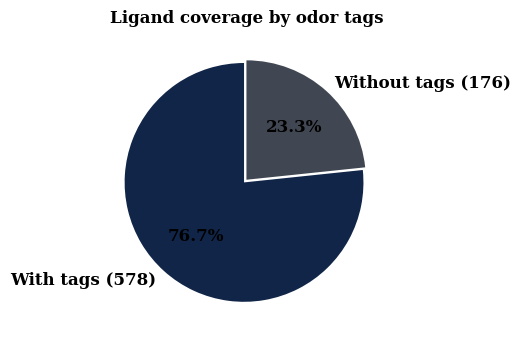

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- inputs you know ---
TOTAL_LIGANDS = 754

# --- coverage numbers ---
n_with_tags = od_expl['InChIKey'].nunique()
n_without   = TOTAL_LIGANDS - n_with_tags
pct_cov     = 100 * n_with_tags / TOTAL_LIGANDS

print(f"Coverage: {n_with_tags} / {TOTAL_LIGANDS} = {pct_cov:.1f}%")

# --- 1) PIE: coverage ---
plt.figure(figsize=(5,5))
labels = [f"With tags ({n_with_tags})", f"Without tags ({n_without})"]
sizes  = [n_with_tags, n_without]
explode = (0.03, 0)  # tiny pop-out for visibility
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, explode=explode, colors=["#102547", "#414752"])
plt.title("Ligand coverage by odor tags")
plt.tight_layout()
plt.savefig("Figures/ligand_tag_coverage_pie.png", dpi=300)
plt.show()

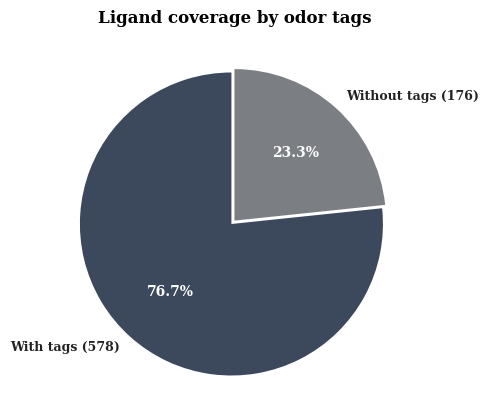

In [32]:
plt.figure(figsize=(5,5))
labels = [f"With tags ({n_with_tags})", f"Without tags ({n_without})"]
sizes  = [n_with_tags, n_without]
explode = (0.03, 0)
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=["#3C485C", "#7B7E83"],
)

# make % texts white and bold
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(10)

# optional: keep label text darker
for t in texts:
    t.set_color('#222')
    t.set_fontsize(9)

plt.title("Ligand coverage by odor tags")
plt.tight_layout()
plt.savefig("Figures/ligand_tag_coverage_pie.png", dpi=300)
plt.show()

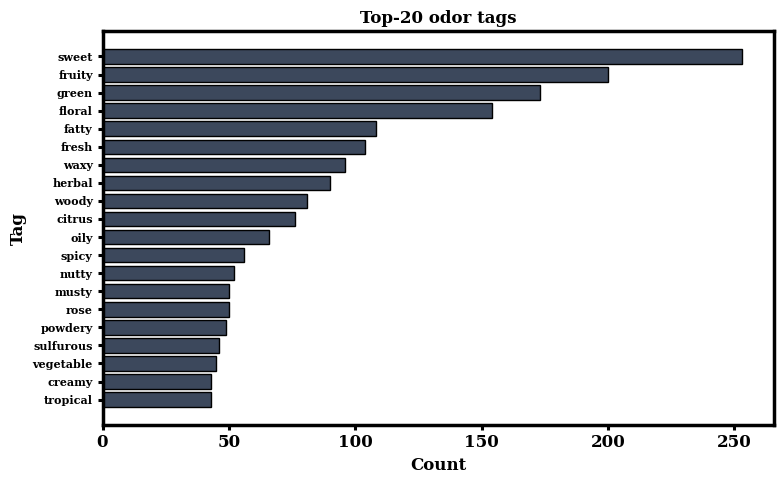

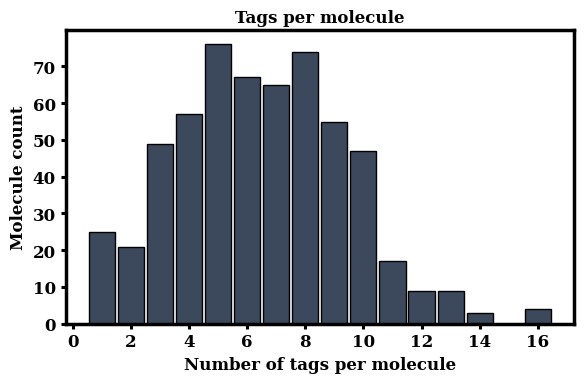

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- inputs ---
# od_expl: columns = ["InChIKey","Odors","tag"]

# Top-20 tags bar chart
tag_counts = od_expl['tag'].str.strip().str.lower().value_counts()
top20 = tag_counts.head(20)

plt.figure(figsize=(8,5))
plt.barh(top20.index[::-1], top20.values[::-1], color="#3C485C", edgecolor='black')
plt.xlabel("Count")
plt.ylabel("Tag")
plt.yticks(fontsize=8)
plt.title("Top-20 odor tags")
plt.tight_layout()
plt.savefig("Figures/top20_odor_tags.png", dpi=300)
plt.show()

# Tags-per-molecule histogram
tags_per_mol = od_expl.groupby('InChIKey')['tag'].nunique()
plt.figure(figsize=(6,4))
plt.hist(tags_per_mol.values, bins=range(1, tags_per_mol.max()+2), align='left', rwidth=0.9, color="#3C485C", edgecolor='black')
plt.xlabel("Number of tags per molecule")
plt.ylabel("Molecule count")
plt.title("Tags per molecule")
plt.tight_layout()
plt.savefig("Figures/tags_per_molecule_histogram.png", dpi=300)
plt.show()


In [2]:
import pandas as pd

In [3]:
chem_df = pd.read_csv("../../../predictions/aggregated/ASR_Predictions_RefTree/inchi_smiles_odors.csv")
chem_df

,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,CC1=C(C(=CC=C1)C)C,NaN
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"balsamic, winey, oily, solvent, fermented, swe..."
...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"meaty, fruity, sulfurous"
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orangeflower, powdery, honey, sweet, floral, o..."
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green"
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN


In [4]:
chem_df["Odors"].notna().sum()

575

In [5]:
# OPTIONAL: compute chemistry with RDKit
# If RDKit isn't installed, install in your env first (e.g., conda). Then run this block.
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen

# chem_df: DataFrame with columns ["InChIKey","SMILES"]
# Merge onto od_expl to get SMILES per InChIKey
merged = (od_expl.assign(tag=od_expl['tag'].str.strip().str.lower())
          .merge(chem_df[['InChIKey','SMILES']], on='InChIKey', how='inner'))

def featurize(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return np.nan, np.nan
    mw = Descriptors.MolWt(m)
    logp = Crippen.MolLogP(m)
    return mw, logp

feat = merged['SMILES'].apply(featurize)
merged['MW']   = [x[0] for x in feat]
merged['logP'] = [x[1] for x in feat]
merged = merged.dropna(subset=['MW','logP'])

# Pick 6–8 common tags to display
top_tags = (merged.groupby('tag')['InChIKey']
            .nunique()
            .sort_values(ascending=False)
            .head(50)
            .index.tolist())

sub = merged[merged['tag'].isin(top_tags)].copy()

# Boxplot: logP
plt.figure(figsize=(8,4))
order = sorted(top_tags, key=lambda t: sub[sub['tag']==t]['logP'].median())
data = [sub[sub['tag']==t]['logP'].values for t in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.ylabel("logP")
plt.title("logP by common odor tags")
plt.xticks(rotation=30, ha='right', fontsize=6)
plt.tight_layout()
plt.show()

# Boxplot: MW
plt.figure(figsize=(8,4))
order = sorted(top_tags, key=lambda t: sub[sub['tag']==t]['MW'].median())
data = [sub[sub['tag']==t]['MW'].values for t in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.ylabel("Molecular weight (Da)")
plt.title("Molecular weight by common odor tags")
plt.xticks(rotation=30, ha='right', fontsize=6)
plt.tight_layout()
plt.show()


NameError: name 'od_expl' is not defined

In [54]:
import numpy as np
import pandas as pd

# assumes you already have `sub` from the previous snippet:
# sub has columns: InChIKey, tag, MW, logP  (and is filtered to your top tags)

def summarize_feature(df, feature, order=None):
    """
    Return a tidy summary table for `feature` grouped by tag:
    count, mean, median, std, min, Q1, Q3, max.
    If `order` is given, rows are ordered accordingly.
    """
    grp = df.groupby('tag')[feature]
    summary = pd.DataFrame({
        'count': grp.count(),
        'mean':  grp.mean(),
        'median': grp.median(),
        'std':   grp.std(ddof=1),
        'min':   grp.min(),
        'Q1':    grp.quantile(0.25),
        'Q3':    grp.quantile(0.75),
        'max':   grp.max(),
    })
    # nice rounding (adjust as you like)
    summary = summary.round({
        'mean': 3, 'median': 3, 'std': 3, 'min': 3, 'Q1': 3, 'Q3': 3, 'max': 3
    })
    if order is not None:
        summary = summary.reindex(order)
    return summary

# Use the same tag orders you used for plotting:
order_logP = sorted(sub['tag'].unique(), key=lambda t: sub[sub['tag']==t]['logP'].median())
order_MW   = sorted(sub['tag'].unique(), key=lambda t: sub[sub['tag']==t]['MW'].median())

logP_summary = summarize_feature(sub, 'logP', order=order_logP)
MW_summary   = summarize_feature(sub, 'MW',   order=order_MW)

print("\n=== logP summary (ordered by median logP, low → high) ===")
print(logP_summary.to_string())

print("\n=== MW summary (ordered by median MW, low → high) ===")
print(MW_summary.to_string())

# OPTIONAL: also print the raw values per tag (handy for deep dives)
for t in order_logP:
    vals = sub.loc[sub['tag']==t, 'logP'].values
    print(f"\n[tag={t}] logP values (n={len(vals)}): {np.round(vals,3)}")

for t in order_MW:
    vals = sub.loc[sub['tag']==t, 'MW'].values
    print(f"\n[tag={t}] MW values (n={len(vals)}): {np.round(vals,3)}")

# OPTIONAL: save to CSVs for your slides/appendix
logP_summary.to_csv("tag_logP_summary.csv")
MW_summary.to_csv("tag_MW_summary.csv")
print("\nSaved: tag_logP_summary.csv, tag_MW_summary.csv")



=== logP summary (ordered by median logP, low → high) ===
           count   mean  median    std    min     Q1     Q3    max
tag                                                               
ethereal      33  1.117   1.187  0.532 -0.432  0.960  1.559  1.766
pungent       40  1.333   1.218  0.837 -0.432  0.930  1.900  3.836
roasted       35  1.672   1.402  0.968  0.477  1.013  1.959  4.289
nutty         52  1.634   1.452  0.828  0.205  1.082  2.161  3.690
winey         26  1.674   1.577  1.065 -0.432  0.778  2.520  3.690
cheesy        42  1.835   1.741  0.821  0.481  1.280  2.258  4.223
meaty         39  2.078   1.759  1.136  0.595  1.250  2.734  5.033
banana        28  1.869   1.927  0.523  0.841  1.535  2.156  2.910
phenolic      40  1.955   1.955  0.711  0.945  1.457  2.365  4.518
sulfurous     46  2.064   1.957  0.955  0.001  1.484  2.703  4.289
balsamic      38  2.299   2.014  1.111  0.779  1.695  2.530  6.031
musty         50  2.021   2.017  1.041  0.205  1.128  2.645  5.033
pin